# Table of Contents

- [1. Discovery Phase](#1.-Discovery-Phase)
  - [Data Selection](#Data-Selection)
  - [Problem Description](#Problem-Description)
  - [Objectives](#Objectives)
- [2. Data Preparation:](#2.-Data-Preparation:)
  - [Reading the data:](#Reading-the-data:)
  - [Classify the columns:](#classify-the-columns:)
  - [Missing data(clean):](#Missing-data(clean):)
  - [Inconsistency(clean):](#Inconsistency(clean):)
  - [Noisy(clean):](#Noisy(clean):)
  - [Removing the outliers and filling NAN values](#removing-the-outliers-and-filling-NAN-values)
- [3. Model Planning:](#3.-Model-Planning:)
  - [Statistical summaries](#Statistical-summaries)
  - [Univariate Graphs](#Univariate-Graphs:)
  - [Bivariate Graphs](#Bivariate-Graphs:)
  - [Advanced Graphs](#Advanced-Graphs:)
 
- [4. Model Building](#4.-Model-Building)
    - [Explanation of Model Performance](#Explanation-of-Model-Performance)
    - [Detailed Metrics Explanation](#Detailed-Metrics-Explanation)
    - [Note on Metric Calculation](#Note-on-Metric-Calculation)
    - [Conclusion](#Conclusion)
    - [Comparison of Model Performance Using SMOTE](#Comparison-of-Model-Performance-Using-SMOTE)
    - [Interpretation of Model Comparison](#Interpretation-of-Model-Comparison)
- [5. Communicate Results:](#5.-Communicate-Results:)
    - [Summary and Conclusion](#Summary-and-Conclusion)
    - [Future Recommendations](#Future-Recommendations)
- [6. Operationalize:](#6.-Operationalize:)
      - [General Guidelines to Adopt the Methodology](#General-Guidelines-to-Adopt-the-Methodology)
      - [Potential Implementation Issues](#Potential-Implementation-Issues)


## 1. Discovery Phase

### Data Selection 

The dataset utilized for this project was sourced from Kaggle, specifically from the "Cardiovascular Diseases Risk Prediction Dataset," available at [this link](https://www.kaggle.com/datasets/alphiree/cardiovascular-diseases-risk-prediction-dataset). This comprehensive dataset provides extensive data on cardiovascular health, focusing on various risk factors associated with heart disease. It includes a range of both numerical and categorical variables that detail the medical, lifestyle, making it an ideal resource for developing predictive models aimed at identifying heart disease risk.

### Problem Description

In recent years, the incidence of heart disease has surged, establishing it as a leading cause of death worldwide. This increase is largely attributed to factors such as lifestyle changes, dietary habits, and an aging population, posing serious challenges to healthcare systems. Despite notable advancements in medical diagnostics and increased health awareness, there is a pressing need for improved early detection and preventive measures. Effective strategies for early identification and management of heart disease are crucial to curbing its prevalence and reducing mortality rates, emphasizing the necessity for innovative solutions in the realm of healthcare.

### Objectives

- **Identify Key Risk Factors**: Determine the major contributing factors that increase the likelihood of developing cardiovascular disease.
- **Analyze the Impact of Risk Factors**: Understand how different variables such as age, diet, physical activity, and genetic predispositions contribute to the risk of CVD.
- **Develop Predictive Models**: Utilize statistical and machine learning techniques to predict individual risk levels of CVD based on health data.

# 2. Data Preparation:

## Reading the data:

In [2]:
#displaying the data and take some information about the type of columns and non-null rows 
import pandas as pd
df = pd.read_csv('CVD_dirty copy.csv', delimiter = ',')
display(df.head())
display(df.info())

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,"150,0","0,032659999999999995",14.54000,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,"-165,0","-77,11",-28.29000,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,"-0,163","0,08845",0.03347,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,"-180,0","93,44",-0.02873,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,"-0,191","-88,45",0.02437,Yes,0.0,8.0,4.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308703 non-null  object 
 1   Checkup                       308669 non-null  object 
 2   Exercise                      308692 non-null  object 
 3   Heart_Disease                 308705 non-null  object 
 4   Skin_Cancer                   308690 non-null  object 
 5   Other_Cancer                  308680 non-null  object 
 6   Depression                    308685 non-null  object 
 7   Diabetes                      308685 non-null  object 
 8   Arthritis                     308688 non-null  object 
 9   Sex                           308686 non-null  object 
 10  Age_Category                  308704 non-null  object 
 11  Height_(cm)                   308706 non-null  object 
 12  Weight_(kg)                   308698 non-nul

None

## classify the columns:

|     Field    |     Type    |
|:------------:|:-----------:|
|General_Health|   ordinal   |
|  Checkup	   | Categorical |
| Exercise     |   Nominal   |
|Heart_Disease |   Nominal   |
|  Skin_Cancer  |  Nominal    |
| Other_Cancer | Nominal     |
|   Depression | Nominal     |
| Diabetes     |  Nominal    |
|Arthritis	   | Nominal     |
|    Sex       |  Nominal    |
| Age_Category |  ordinal    |
|  Height_(cm) |   Numeric   |
|  Weight_(kg) |   Numeric   |
|  BMI	       |   Numeric   |
|Smoking_History 1| Nominal    |
|Alcohol_Consumption| Numeric|
|Fruit_Consumption| Numeric  |
|Green_Vegetables_Consumption| Numeric |
|FriedPotato_Consumption| Numeric   |


## Missing data(clean):

In [3]:
#missing data(clean)

#displaying the number of null values for each column
display(df.isna().sum())

null_columns = df.columns[df.isna().any()]
display(null_columns)

#replacing each null value by the mean if a column is numerical or the mode if it is categorical
for i in null_columns:
    value = df[i].mean() if df[i].dtype!='object' else df[i].mode()[0]
    df[i].fillna(value,inplace = True)

display(df.head(5))

#ensuring that each column was teated correctly
null_columns = df.columns[df.isna().any()]
display(null_columns)  
display(df.info())

General_Health                  151
Checkup                         185
Exercise                        162
Heart_Disease                   149
Skin_Cancer                     164
Other_Cancer                    174
Depression                      169
Diabetes                        169
Arthritis                       166
Sex                             168
Age_Category                    150
Height_(cm)                     148
Weight_(kg)                     156
BMI                             138
Smoking_History                 172
Alcohol_Consumption             169
Fruit_Consumption               131
Green_Vegetables_Consumption    144
FriedPotato_Consumption         135
dtype: int64

Index(['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer',
       'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex',
       'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History',
       'Alcohol_Consumption', 'Fruit_Consumption',
       'Green_Vegetables_Consumption', 'FriedPotato_Consumption'],
      dtype='object')

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,"150,0","0,032659999999999995",14.54000,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,"-165,0","-77,11",-28.29000,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,"-0,163","0,08845",0.03347,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,"-180,0","93,44",-0.02873,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,"-0,191","-88,45",0.02437,Yes,0.0,8.0,4.0,0.0


Index([], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  object 
 12  Weight_(kg)                   308854 non-nul

None

## Inconsistency(clean):

In [4]:
#inconsistency(clean)

#some columns must be numerical, so this step is to convert categorical into numerical
df[['Height_(cm)', 'Weight_(kg)']] = df[['Height_(cm)', 'Weight_(kg)']].applymap(lambda x : float(x.replace(',','.')))

display(df.head())
display(df.info())


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.000,0.03266,14.54000,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,-165.000,-77.11000,-28.29000,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,-0.163,0.08845,0.03347,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,-180.000,93.44000,-0.02873,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,-0.191,-88.45000,0.02437,Yes,0.0,8.0,4.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

None

## Noisy(clean):

In [5]:
#noisy(clean)

# we clean each numerical column by removing negative and fit the numbers
for col in ['Height_(cm)', 'Weight_(kg)', 'BMI']:
    df[col] = df[col].apply(lambda x: x if x >0 else abs(x))
    df[col] = df[col].apply(lambda x: x  if x > 1  else x*1000)
display(df.head())    


,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


## removing the outliers and filling NAN values

In [6]:
#now we need to remove the outliers and filling NAN with the mean in numerical columns
import numpy as np
display(df.describe())

#we need to find the upper and whisker limits, so this code is to calculate them by using a dictonary.

limits = {}
name_of_columns = df.select_dtypes(exclude='object').columns
for col in name_of_columns:
    #finding the upper whisker limit and lower whisker limit by the datarame(df.describe())
    Q1 = df.describe().loc['25%' ,col]
    Q3 = df.describe().loc['75%' ,col]
    IQR = Q3 -Q1
    #calculting the upper and lower limit
    upplimit = np.round(Q3 +(1.5 * IQR) ,2)
    lowlimit = np.round(Q1 -(1.5 * IQR),2)
    
    #some of the columns have negative lower limit becasue Q1 is zero,
    #so we do not need change min to negtaive number
    if lowlimit <0:
        limits[col] = (None, upplimit)
    else:    
        limits[col] = (lowlimit, upplimit)
     


# here we iterate through the columns and select the rows that have values above the upper or below the 
#lower whiskers limits and repLce them by nan values and fill them by the mean
for col ,(lower ,upper) in limits.items():
    if lower is None:
        df.loc[(df[col] > upper) ,col] = np.nan
        
    else:    
        df.loc[(df[col] > upper) | (df[col] <lower) ,col] = np.nan  
       
    df[col].fillna(df[col].mean() ,inplace = True)
    
    
display(df.describe())

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.613853,83.592124,28.616708,5.096613,29.835124,15.110729,6.296383
std,10.655356,21.338345,6.536004,8.198103,24.870333,14.922161,8.580765
min,91.000000,24.950000,7.481968,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.840000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000


,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.609246,81.961656,27.976970,2.475984,18.394420,12.965176,4.668644
std,10.415414,18.358684,5.287383,3.527751,9.678206,9.812710,4.058624
min,142.000000,29.940000,12.870000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,18.394420,12.000000,4.000000
75%,178.000000,92.990000,31.170000,3.000000,30.000000,20.000000,8.000000
max,200.000000,136.000000,43.280000,15.000000,56.000000,44.000000,17.000000


# 3. Model Planning:

## Statistical summaries

In [ ]:

#statistical summaries
print('Summary of numerical statistics:')
display(df.describe(include='number'))
print('Summary of non-numerical statistics:')
display(df.describe(exclude='number'))

##  Univariate Graphs:

## Plots for the non-numeric data columns

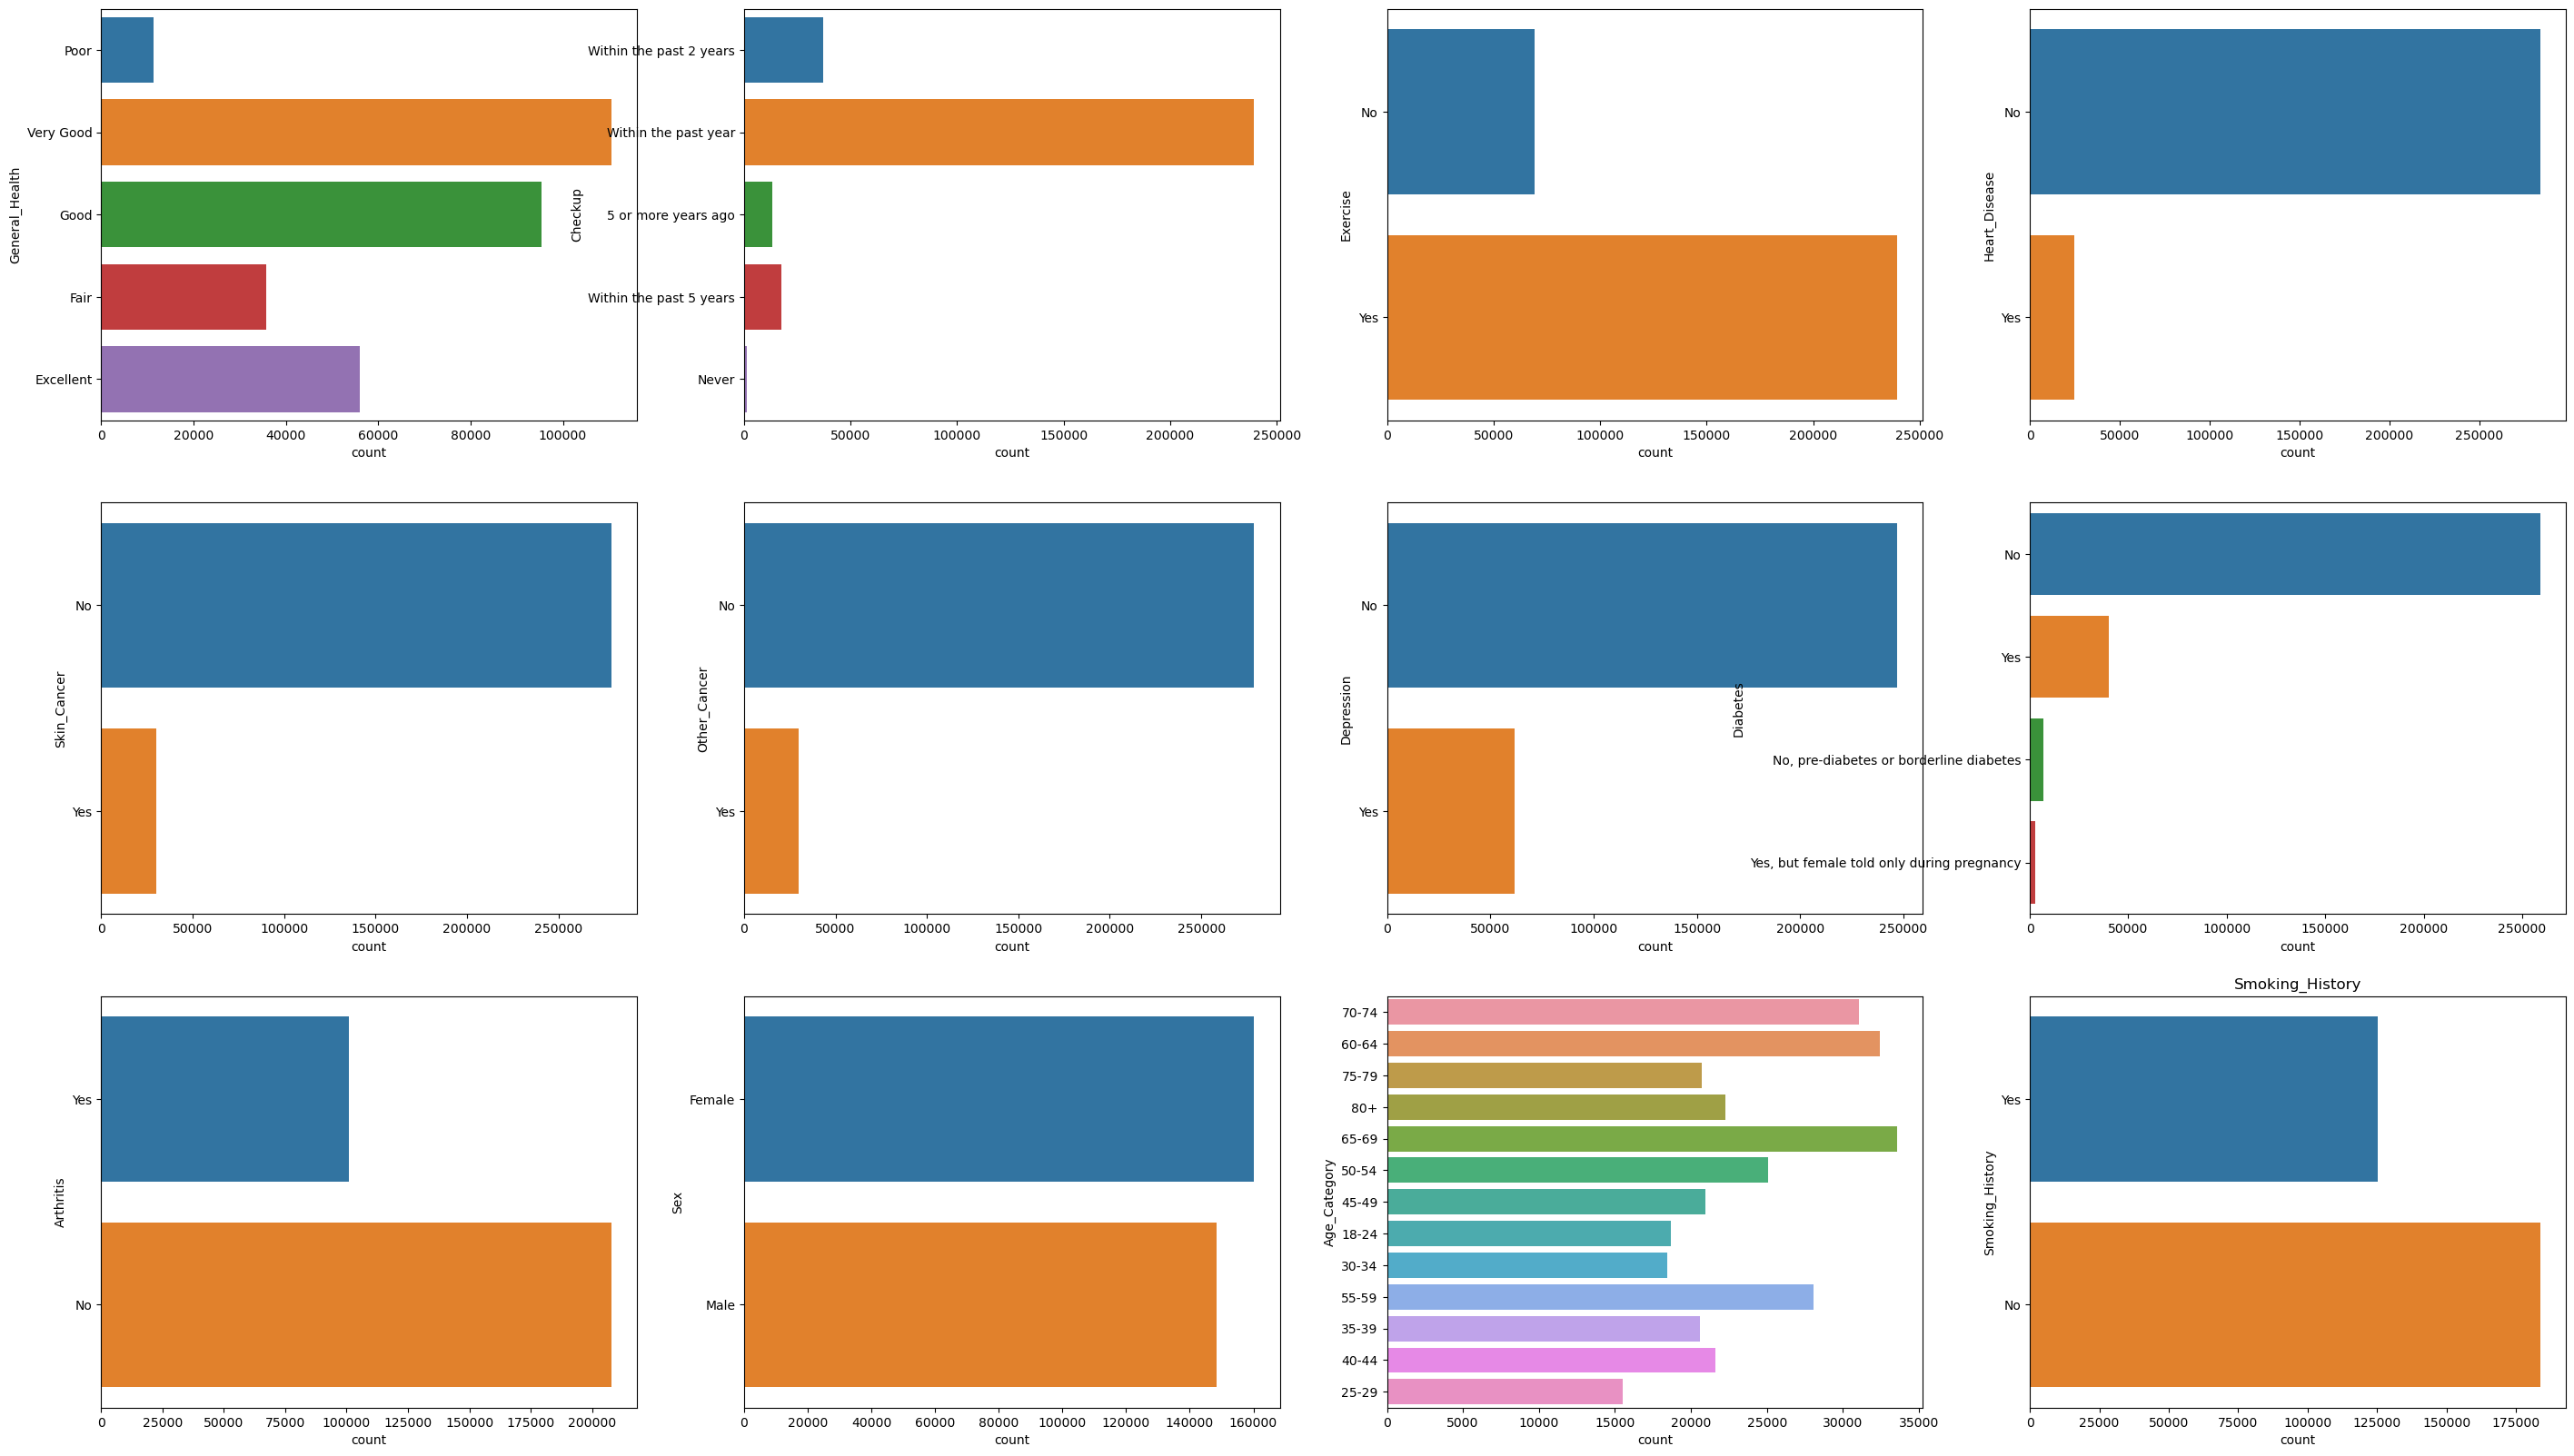

In [7]:
# This is a Univariate Graph - Categorical Data
# This is a Line Plot
#plots for the non-numeric data columns
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns
cat_columns = df.select_dtypes(exclude='number').columns

fig,axes = plt.subplots(3, 4, figsize=(35,20))
for ind,col in enumerate(cat_columns):
    
    sns.countplot(y=col,data=df,ax=axes.flatten()[ind])
    plt.title(col)
plt.show()

## Analysis Based on Provided Bar Charts: Observations and Conclusions

### Observations:
1. **General Health**: 
   - The distribution indicates that many respondents rate their health as "Very Good" or "Good," suggesting a relatively healthy population. Fewer respondents report their health as "Poor".

2. **Checkup Frequency**:
   - Most individuals had their last medical checkup "Within the past year," indicating regular health monitoring among the survey respondents.

3. **Chronic Conditions**:
   - **Skin Cancer and Other Cancer**: The majority do not report having skin cancer or other types of cancer.
   - **Heart Disease**: A vast majority report no heart disease.
   - **Depression**: A notable portion of the population reports suffering from depression.
   - **Diabetes**: Most do not have diabetes, although a segment does, including some cases of gestational diabetes.

4. **Arthritis and Exercise**: 
   - Insights into the proportion of the population engaging in regular physical activity versus those suffering from arthritis.

5. **Sex**:
   - Nearly even distribution between male and female respondents.

6. **Age Category**:
   - Respondents span a range of ages, with a significant number in the 65-74 age bracket, indicating an older demographic.

7. **Smoking History**:
   - A large segment of the population has never smoked, which may reflect successful public health messaging.



## Plots for the numeric data columns

In [ ]:
# This is a Univariate Graph - Numerical Data
# This is a Box Plot
# This is a Histogram
#plots for the numeric data columns
num_columns= df.select_dtypes(exclude='object').columns


for col in num_columns:
    plt.figure(figsize=(12, 6))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col],bins = 15, kde=True)
    plt.title(f'Histogram of {col}')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()



## Analysis of Numeric Data Columns: Observations and Conclusions

### Height and Weight
- **Height**:
  - **Histogram**: Shows a bimodal distribution, suggesting potential gender differences or other demographic variations.
  - **Boxplot**: Few outliers, indicating that extreme heights are not common.
- **Weight**:
  - **Histogram**: Roughly normal distribution with slight right skewness, indicating a segment is heavier than average.
  - **Boxplot**: Presence of outliers on the heavier side highlights some extreme values.

### Body Mass Index (BMI)
- **Histogram**: Normal distribution centered around the overweight category (BMI 25-30).
- **Boxplot**: Few outliers, primarily on the higher side, indicating some very high BMI values among respondents.

### Dietary Consumption
- **Alcohol Consumption**:
  - **Histogram**: Highly skewed towards lower consumption, with most respondents consuming little alcohol.
  - **Boxplot**: Outliers suggest a few individuals with significantly higher alcohol consumption.
- **Fruit Consumption**:
  - **Histogram**: Shows peaks at various levels, indicative of specific common habits or survey response options.
  - **Boxplot**: Indicates few outliers, suggesting that extreme fruit consumption is uncommon.
- **Green Vegetables Consumption**:
  - **Histogram**: Multiple peaks possibly indicating common portion sizes or consumption frequency.
  - **Boxplot**: Few outliers, with consumption generally within a typical range.
- **Fried Potato Consumption**:
  - **Histogram**: Features several peaks, likely indicating common portion sizes or consumption frequencies.
  - **Boxplot**: Outliers are present but not extreme, showing varied but generally moderate consumption levels.



##  Bivariate Graphs:

### Categorical Vs Categorical

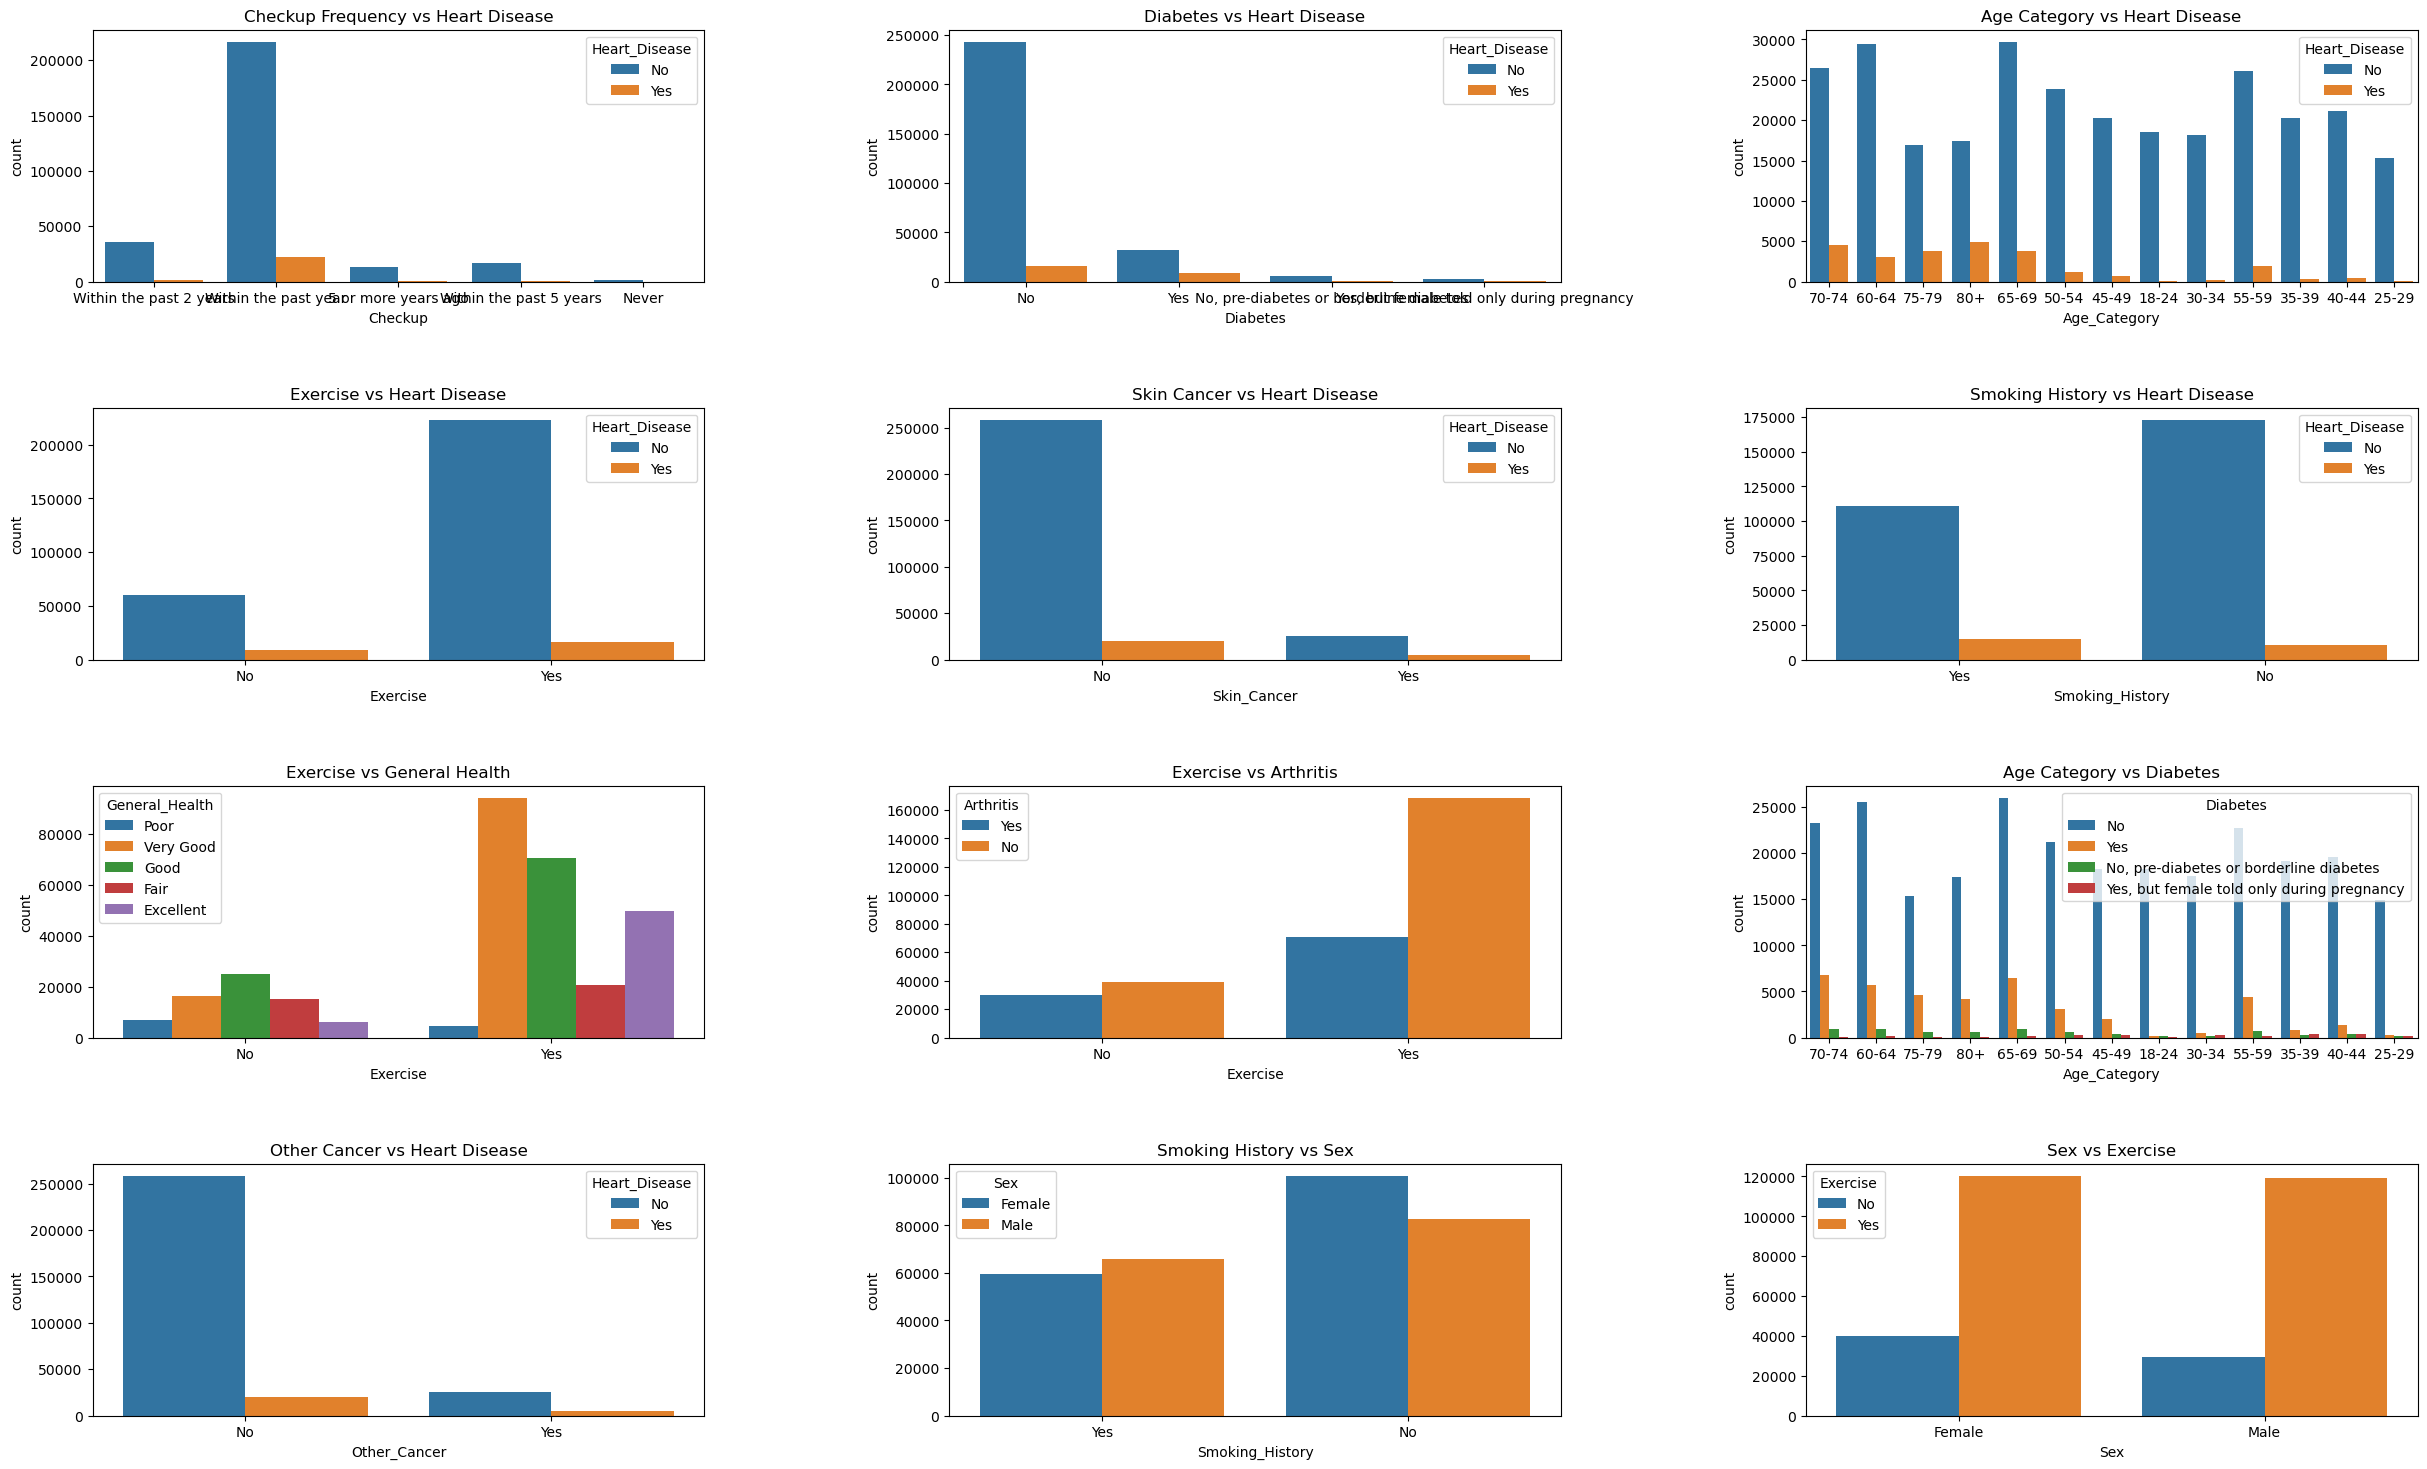

In [8]:
# This is a Bivariate Graph - Categorical vs Target
# This is a Histogram
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set up the figure and axes for selected plots
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(30, 18))
plt.subplots_adjust(hspace=0.5, wspace=0.4)

# Plot 1: Checkup Frequency vs Heart Disease
sns.countplot(x='Checkup', hue='Heart_Disease', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Checkup Frequency vs Heart Disease')

# Plot 2: Diabetes vs Heart Disease
sns.countplot(x='Diabetes', hue='Heart_Disease', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Diabetes vs Heart Disease')

# Plot 3: Age Category vs Heart Disease
sns.countplot(x='Age_Category', hue='Heart_Disease', data=df, ax=axes[0, 2])
axes[0, 2].set_title('Age Category vs Heart Disease')

# Plot 4: Exercise vs Heart Disease
sns.countplot(x='Exercise', hue='Heart_Disease', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Exercise vs Heart Disease')

# Plot 5: Skin Cancer vs Heart Disease
sns.countplot(x='Skin_Cancer', hue='Heart_Disease', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Skin Cancer vs Heart Disease')

# Plot 6: Smoking History vs Heart Disease
sns.countplot(x='Smoking_History', hue='Heart_Disease', data=df, ax=axes[1, 2])
axes[1, 2].set_title('Smoking History vs Heart Disease')

# Plot 7: Exercise vs General Health
sns.countplot(x='Exercise', hue='General_Health', data=df, ax=axes[2, 0])
axes[2, 0].set_title('Exercise vs General Health')

# Plot 8: Exercise vs Arthritis
sns.countplot(x='Exercise', hue='Arthritis', data=df, ax=axes[2, 1])
axes[2, 1].set_title('Exercise vs Arthritis')

# Plot 9: Age Category vs Diabetes
sns.countplot(x='Age_Category', hue='Diabetes', data=df, ax=axes[2, 2])
axes[2, 2].set_title('Age Category vs Diabetes')

# Plot 10: Other Cancer vs Heart Disease
sns.countplot(x='Other_Cancer', hue='Heart_Disease', data=df, ax=axes[3, 0])
axes[3, 0].set_title('Other Cancer vs Heart Disease')

# Plot 11: Smoking History vs Sex
sns.countplot(x='Smoking_History', hue='Sex', data=df, ax=axes[3, 1])
axes[3, 1].set_title('Smoking History vs Sex')

# Plot 12: Sex vs Exercise
sns.countplot(x='Sex', hue='Exercise', data=df, ax=axes[3, 2])
axes[3, 2].set_title('Sex vs Exercise')

plt.show()

## Observations on Categorical Data Plots

### 1. Checkup Frequency vs Heart Disease
- **Observation**: There seems to be a correlation where regular checkups are associated with lower incidences of heart disease, suggesting that early detection and ongoing management might be effective.

### 2. Diabetes vs Heart Disease
- **Observation**: A strong association between diabetes and heart disease is evident, indicating that individuals with diabetes are at a higher risk of developing heart-related issues.

### 3. Age Category vs Heart Disease
- **Observation**: The prevalence of heart disease increases significantly with age, highlighting older age groups as high-risk populations.

### 4. Exercise vs Heart Disease
- **Observation**: Physical activity appears to reduce the risk of heart disease, showcasing the protective benefits of regular exercise.

### 5. Skin Cancer vs Heart Disease
- **Observation**: While the relationship may be indirect, there could be shared risk factors influencing both skin cancer and heart disease.

### 6. Smoking History vs Heart Disease
- **Observation**: Smoking is confirmed as a major risk factor for heart disease, with higher rates observed among smokers.

### 7. Exercise vs General Health
- **Observation**: Individuals who engage in regular exercise generally report better overall health, emphasizing the importance of physical activity for maintaining good health.

### 8. Exercise vs Arthritis
- **Observation**: The impact of exercise on arthritis might vary, with it potentially helping in some cases while exacerbating symptoms in others.

### 9. Age Category vs Diabetes
- **Observation**: An increase in diabetes prevalence is noted as age increases, reflecting common metabolic changes or increased vulnerability in older populations.

### 10. Other Cancer vs Heart Disease
- **Observation**: There is an observable increase in cardiovascular risk among individuals with a history of other cancers, possibly due to overlapping risk factors or the effects of cancer treatments.

### 11. Smoking History vs Sex
- **Observation**: This plot can reveal significant gender disparities in smoking habits, which could inform targeted public health interventions.

### 12. Sex vs Exercise
- **Observation**: Differences in exercise frequency between genders may be influenced by a variety of factors, including social norms and personal health choices.

Each of these observations can guide targeted health interventions and inform policy decisions aimed at improving public health outcomes based on identified risk factors and behaviors.


## Numerical Vs Numerical

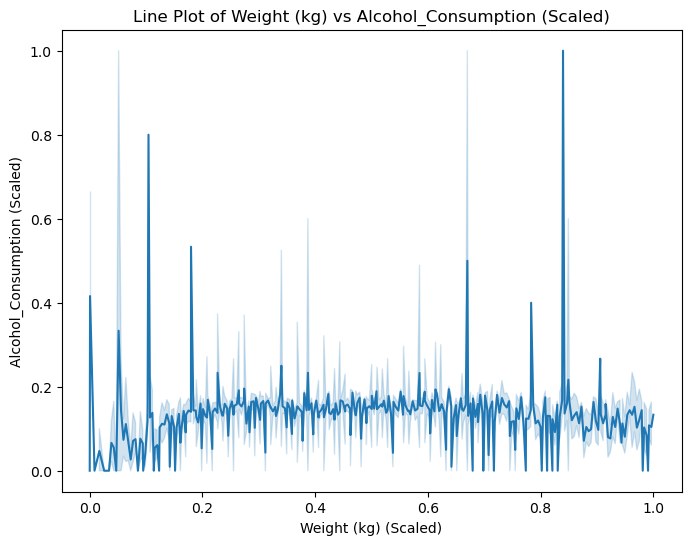

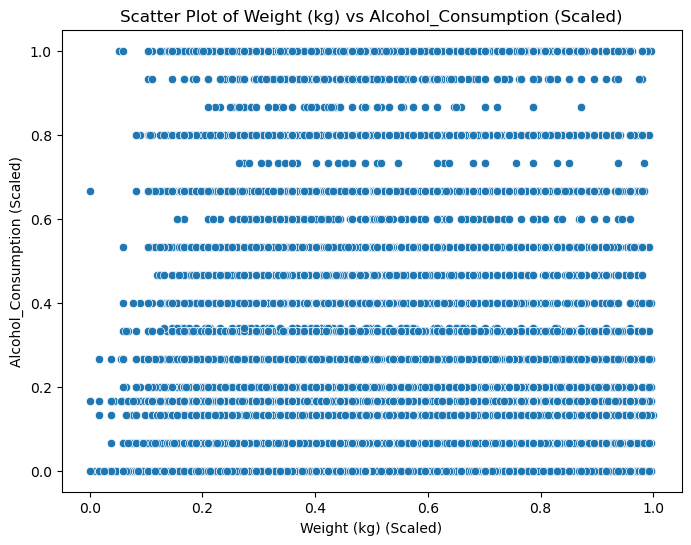

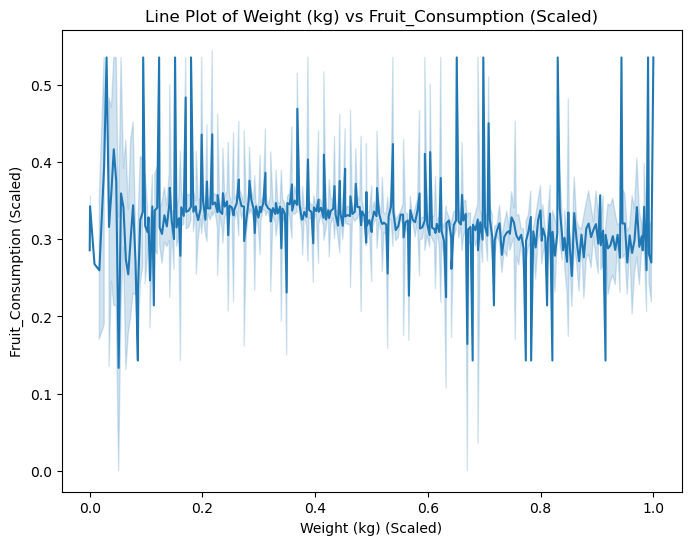

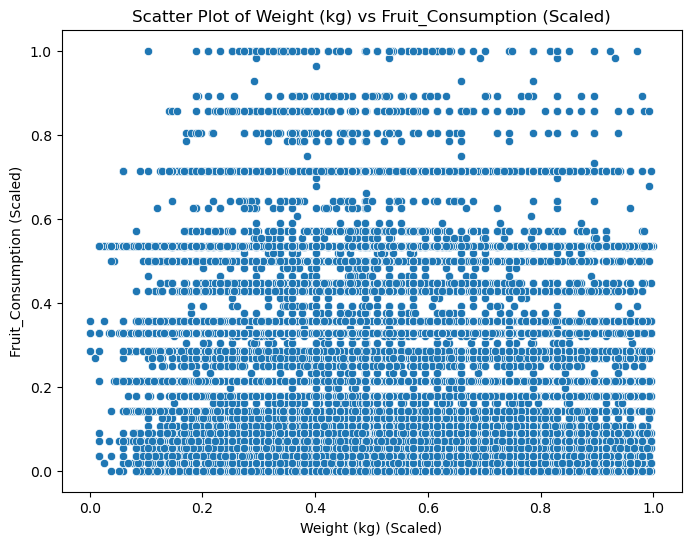

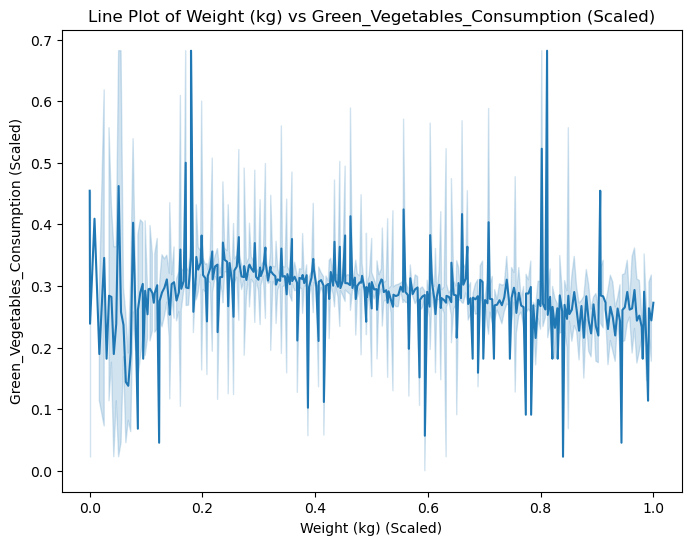

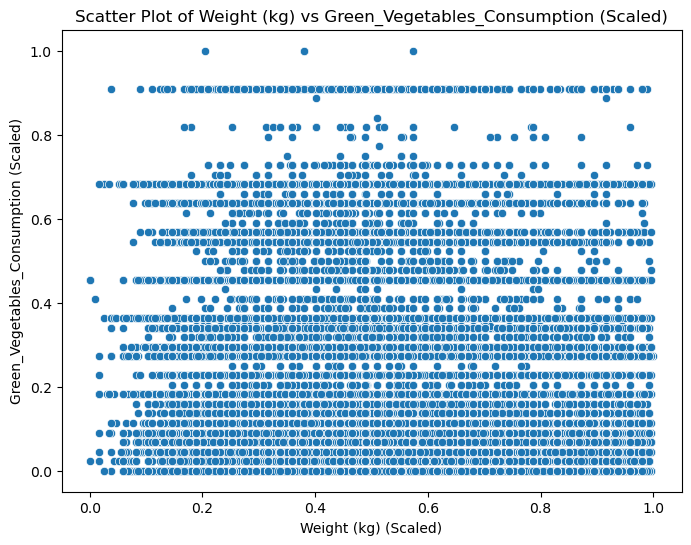

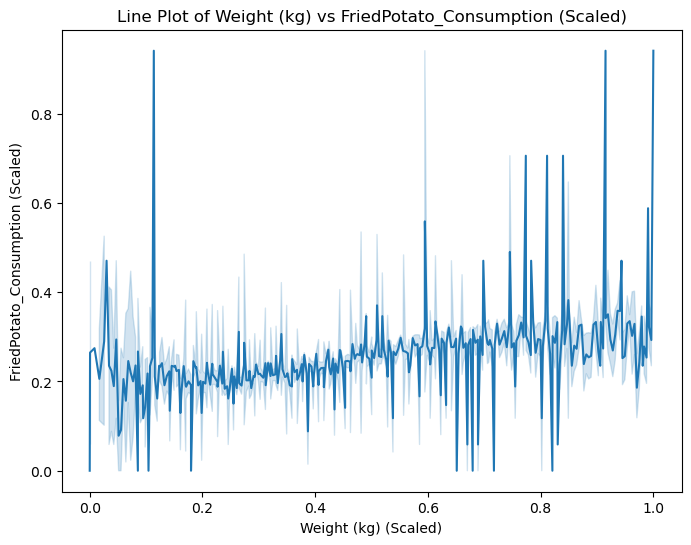

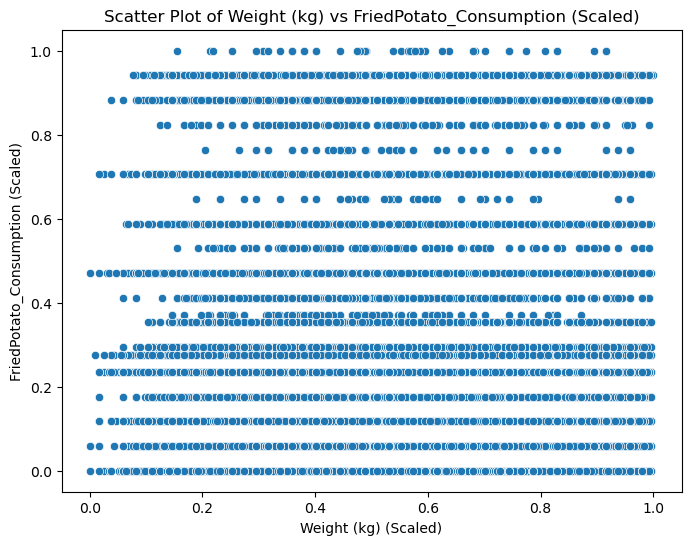

In [9]:
# This is a Line Plot
# This is a Scatter Plot
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# List of numerical variables
num_columns = ['Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

#Scaling the data
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[num_columns] = scaler.fit_transform(df[num_columns])
df_scaled['Weight_(kg)'] = scaler.fit_transform(df[['Weight_(kg)']])

# Create scatter plots and line plots for each pair of numerical variables using Weight_(kg)
for col in num_columns:
    plt.figure(figsize=(8, 6))  # Line plot
    sns.lineplot(x=df_scaled['Weight_(kg)'], y=df_scaled[col])
    plt.title(f'Line Plot of Weight (kg) vs {col} (Scaled)')
    plt.xlabel('Weight (kg) (Scaled)')
    plt.ylabel(f'{col} (Scaled)')
    plt.show()
    
    plt.figure(figsize=(8, 6))  # Scatter plot
    sns.scatterplot(x=df_scaled['Weight_(kg)'], y=df_scaled[col])
    plt.title(f'Scatter Plot of Weight (kg) vs {col} (Scaled)')
    plt.xlabel('Weight (kg) (Scaled)')
    plt.ylabel(f'{col} (Scaled)')
    plt.show()

## Observations from Plots: Weight vs Consumption Metrics

### 1. Weight vs Alcohol Consumption
- **Line Plot**: Displays a subtle upward trend, hinting at a possible weak correlation between weight increase and higher alcohol consumption levels.
- **Scatter Plot**: The points are mostly scattered, with a slight density increase at lower alcohol consumption levels, suggesting a weak relationship, if any.

### 2. Weight vs Fruit Consumption
- **Line Plot**: The plot remains relatively flat across different weights, indicating no significant correlation between weight and the amount of fruit consumed.
- **Scatter Plot**: Data points are widely spread, showing no apparent trend or pattern, confirming the absence of a correlation between weight and fruit consumption.

### 3. Weight vs Green Vegetables Consumption
- **Line Plot**: Similar to fruit consumption, the line plot shows no significant changes across weight ranges, suggesting a lack of correlation between weight and green vegetable consumption.
- **Scatter Plot**: Uniform scatter across the plot supports the observation that vegetable consumption does not vary significantly with weight.

### 4. Weight vs Fried Potato Consumption
- **Line Plot**: Shows variability which may suggest a slight positive correlation; as fried potato consumption increases, weight appears to increase slightly.
- **Scatter Plot**: A broader distribution of data at higher fried potato consumption levels might indicate that higher consumption is associated with higher weight, albeit the correlation is not strongly defined.




## Categorical Vs Numerical

In [ ]:
# This is a Univariate Graph - Categorical Data
# This is a Box Plot
import matplotlib.pyplot as plt
import seaborn as sns

cat_columns = ['General_Health', 'Heart_Disease', 'Depression', 'Exercise', 'Diabetes']
num_columns = ['BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']
# Generate box plots for each pair of categorical and numerical variables
for cat_column in cat_columns:
    for num_column in num_columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=df[cat_column], y=df[num_column])
        plt.title(f'Box Plot of {num_column} by {cat_column}')
        plt.xticks(rotation=45)
        plt.show()


# Observations from Box Plots: Health Conditions vs Dietary and Lifestyle Factors

### General Health vs BMI, Alcohol Consumption, and Diet
- **BMI**: Individuals with "Poor" general health tend to have higher BMI values, indicating a correlation between higher body mass and perceived health issues. Conversely, lower BMIs generally correspond with "Good" or "Very Good" health ratings.
- **Alcohol Consumption**: There is no clear trend between alcohol consumption and general health, indicating variability in drinking habits across health categories.
- **Diet (Fruit, Vegetables, Fried Potato Consumption)**: Higher consumption of fruits and vegetables is associated with better general health ratings. Conversely, higher fried potato consumption is slightly more prevalent among those with "Poor" health.

### Heart Disease vs Dietary Factors
- **BMI**: Higher BMI is more in individuals with heart disease, supporting known health risks associated with obesity.
- **Diet**: Dietary habits, particularly higher fried potato consumption, appear to influence heart disease, suggesting an impact from less healthy food choices.

### Depression, Exercise, and Diabetes Correlations
- **Depression and Diet**: No clear dietary pattern emerges for individuals with depression, suggesting the complexity of factors influencing mental health.
- **Exercise vs BMI**: Regular physical activity is associated with lower BMI, indicating its effectiveness in managing body weight.
- **Diabetes and BMI**: Higher BMI levels are distinctly associated with diabetes, highlighting the importance of weight management in diabetes prevention and management.


## Advanced Graphs:

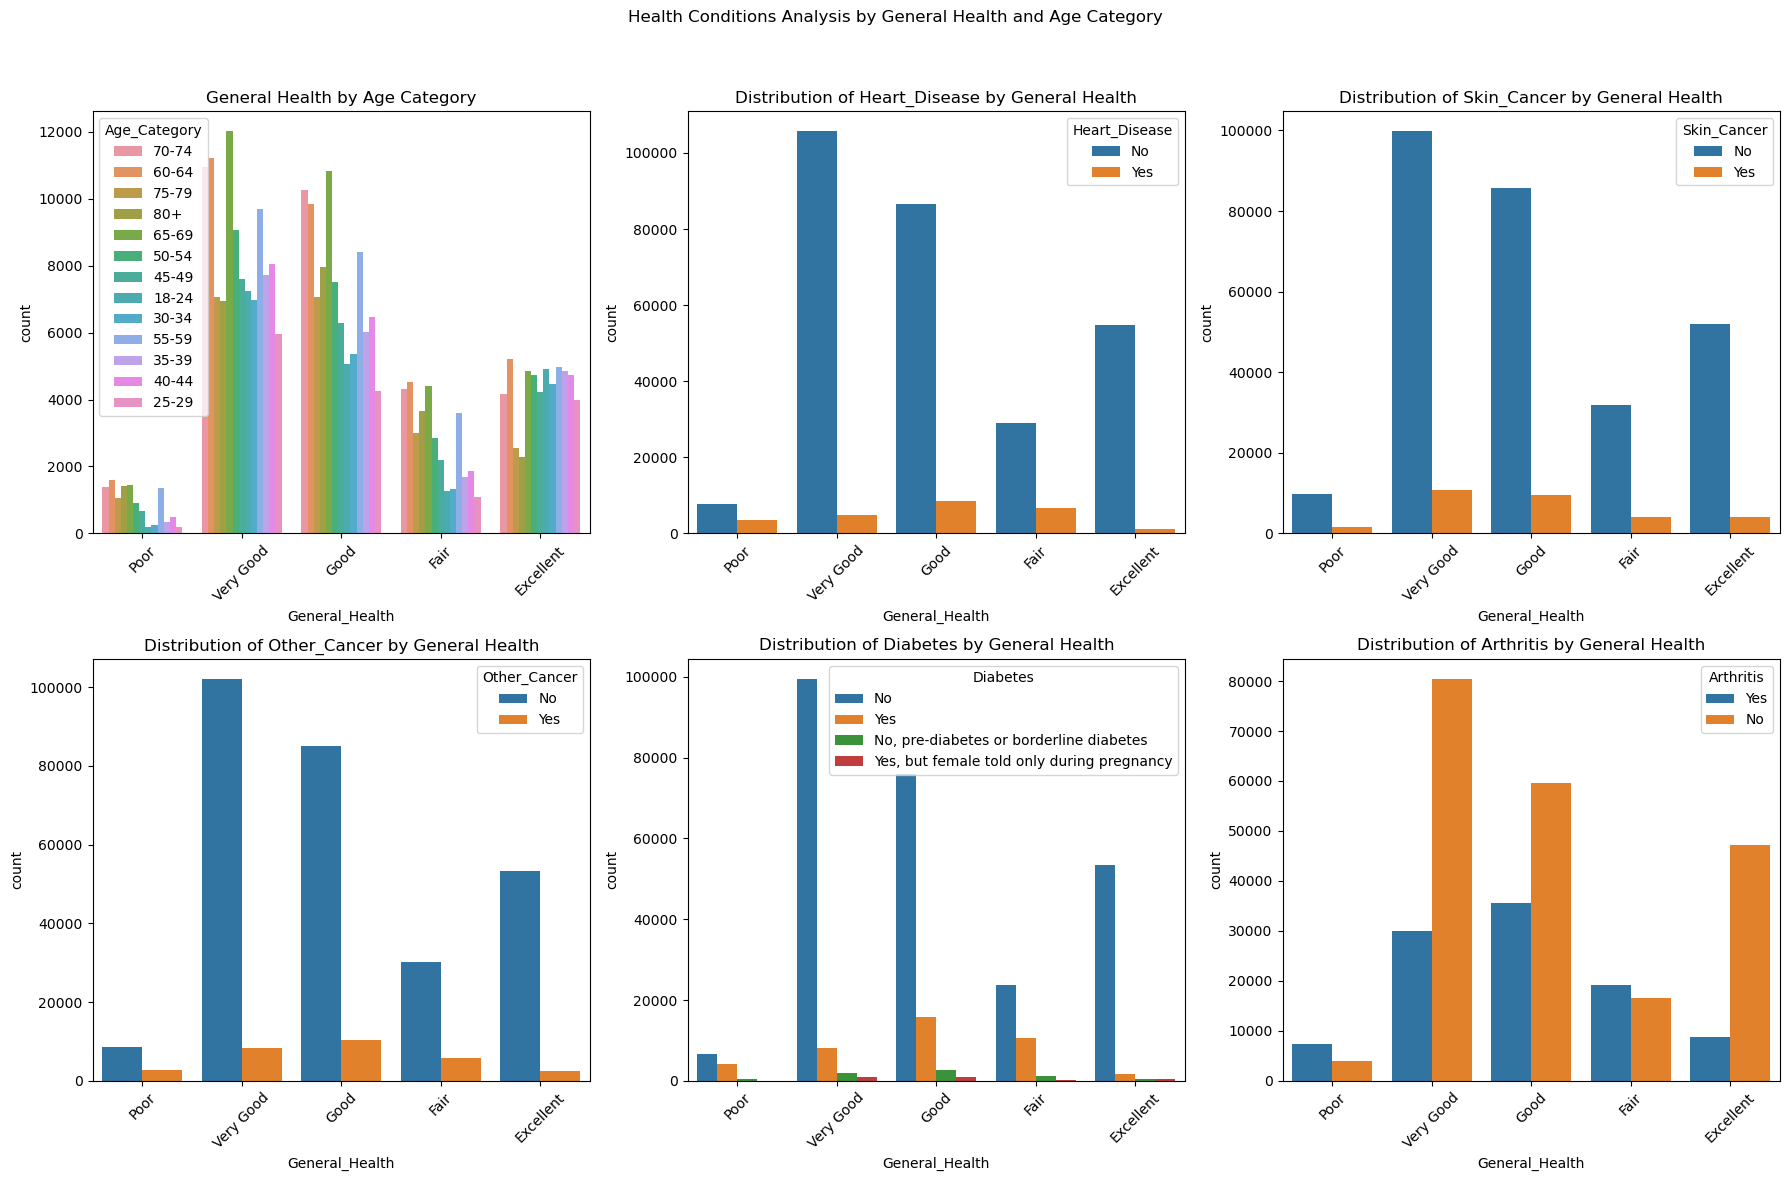

<Figure size 640x480 with 0 Axes>

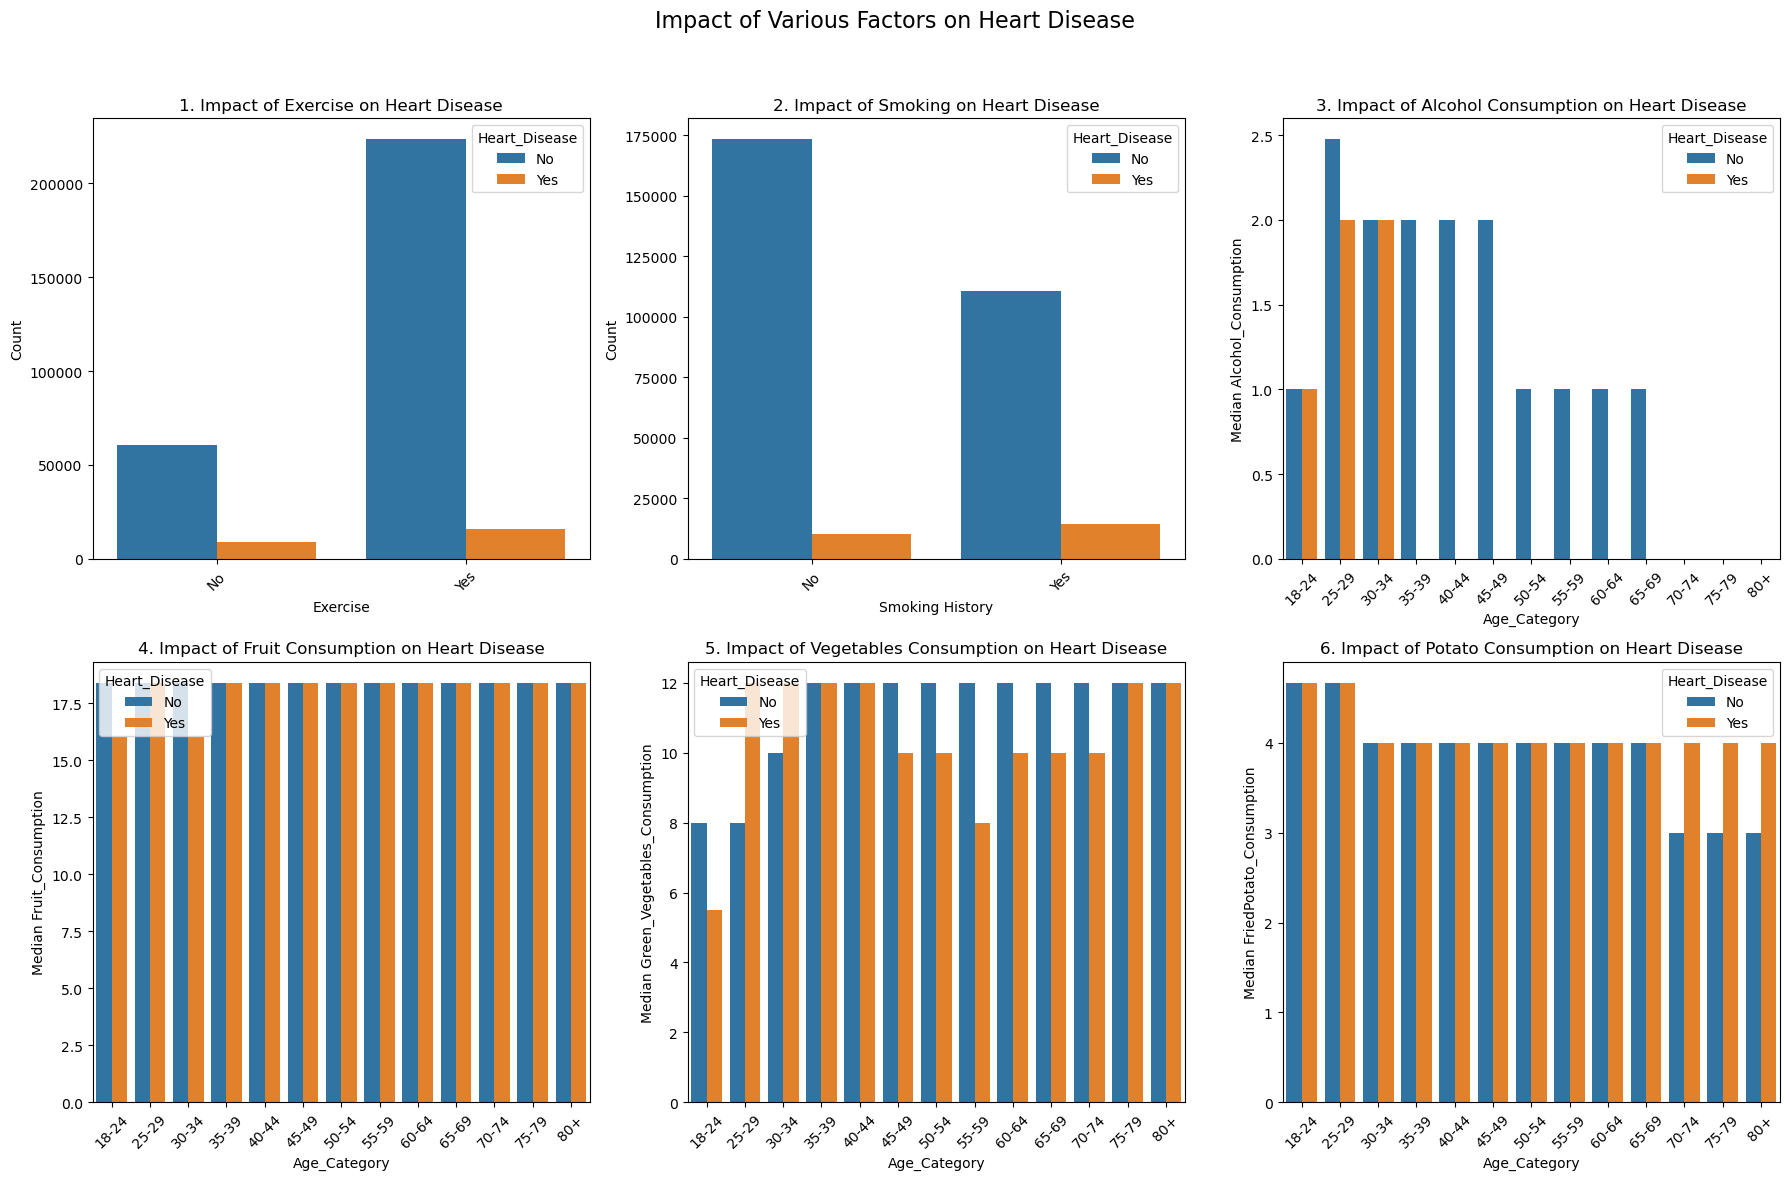

<Figure size 640x480 with 0 Axes>

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns

# Setting up the subplot for the multivariate analysis
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))  # Adjust subplot grid size as needed
fig.suptitle('Health Conditions Analysis by General Health and Age Category')

# First subplot for General Health vs Age Category
sns.countplot(data=df, x='General_Health', hue='Age_Category', ax=axes[0, 0])
axes[0, 0].set_title('General Health by Age Category')
axes[0, 0].tick_params(axis='x', rotation=45)

# Subplots for each disease condition
disease_conditions = ['Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Diabetes', 'Arthritis']
for i, disease in enumerate(disease_conditions, start=1):
    row, col = divmod(i, 3)
    sns.countplot(data=df, x='General_Health', hue=disease, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {disease} by General Health')
    axes[row, col].tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust the rect if the titles overlap

# Show the plot
plt.show()
plt.savefig('Health_Conditions_Analysis.png')


# Function to create a grouped bar chart
def create_grouped_bar_chart(data, x_col, y_col, hue_col, ax, title, x_label, y_label):
    grouped_data = data.groupby([x_col, hue_col])[y_col].size().reset_index(name='count')
    sns.barplot(data=grouped_data, x=x_col, y='count', hue=hue_col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend(title=hue_col)
    ax.tick_params(axis='x', rotation=45)

# Function to create a median bar chart
def create_median_bar_chart(data, x_col, y_col, hue_col, ax, title):
    grouped_data = data.groupby([x_col, hue_col], as_index=False)[y_col].median()
    sns.barplot(data=grouped_data, x=x_col, y=y_col, hue=hue_col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(f'Median {y_col}')
    ax.legend(title=hue_col)
    ax.tick_params(axis='x', rotation=45)

# Prepare the subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Impact of Various Factors on Heart Disease', fontsize=16)

# Create the grouped bar charts for exercise and smoking history
create_grouped_bar_chart(df, 'Exercise', 'Heart_Disease', 'Heart_Disease', axes[0, 0], 
                         '1. Impact of Exercise on Heart Disease', 'Exercise', 'Count')
create_grouped_bar_chart(df, 'Smoking_History', 'Heart_Disease', 'Heart_Disease', axes[0, 1], 
                         '2. Impact of Smoking on Heart Disease', 'Smoking History', 'Count')

# List of numerical columns to analyze
columns = ['Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']
titles = ["Alcohol Consumption", "Fruit Consumption", "Vegetables Consumption", "Potato Consumption"]

# Loop through the numerical columns to create median bar charts
for i, col in enumerate(columns):
    row, col_index = divmod(i + 2, 3)
    create_median_bar_chart(df, 'Age_Category', col, 'Heart_Disease', axes[row, col_index], 
                            f"{i + 3}. Impact of {titles[i]} on Heart Disease")

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show the plot
plt.show()
plt.savefig('Impact_of_Factors_on_Heart_Disease.png')



# Observations based on the preivous graphs


## Interpretation of Impact of Various Factors on Heart Disease

### 1. Impact of Exercise on Heart Disease
- **Observation**: The bar chart indicates that individuals who do not exercise have a higher count of heart disease cases compared to those who do exercise.
- **Conclusion**: Lack of exercise is strongly associated with an increased risk of heart disease, underscoring the importance of physical activity for heart health.

### 2. Impact of Smoking on Heart Disease
- **Observation**: The chart shows a higher prevalence of heart disease among individuals with a history of smoking.
- **Conclusion**: Smoking history is a significant risk factor for heart disease, highlighting the need for smoking cessation programs to improve cardiovascular health.

### 3. Impact of Alcohol Consumption on Heart Disease
- **Observation**: Median alcohol consumption tends to be higher in individuals without heart disease, though the difference is not pronounced.
- **Conclusion**: Moderate alcohol consumption may not have a significant adverse effect on heart disease prevalence, but excessive consumption is still a risk factor.

### 4. Impact of Fruit Consumption on Heart Disease
- **Observation**: Median fruit consumption is higher among individuals without heart disease.
- **Conclusion**: Higher fruit consumption is associated with a lower risk of heart disease, suggesting the benefits of a diet rich in fruits for heart health.

### 5. Impact of Vegetables Consumption on Heart Disease
- **Observation**: Individuals without heart disease consume a median amount of vegetables similar to those with heart disease.
- **Conclusion**: While vegetable consumption is generally beneficial, it may not show a strong direct impact on heart disease in isolation; overall dietary patterns are important.

### 6. Impact of Potato Consumption on Heart Disease
- **Observation**: Median fried potato consumption is higher among individuals with heart disease.
- **Conclusion**: High consumption of fried potatoes is associated with an increased risk of heart disease, emphasizing the need to limit intake of fried and unhealthy foods.


## Interpretation of Health Conditions Analysis by General Health and Age Category

### 1. General Health by Age Category
- **Observation**: The graph displays a correlation between age and reported general health, with younger age groups generally reporting better health. There is a noticeable increase in "Poor" health reports among the older age groups, particularly those aged 75 and above.
- **Conclusion**: Age is a significant determinant of general health, with older age groups more likely to report poorer health outcomes.

### 2. Distribution of Heart Disease by General Health
- **Observation**: Higher instances of heart disease are observed in categories with poorer general health. The "Poor" and "Fair" health categories show significantly higher rates of heart disease.
- **Conclusion**: There is a strong correlation between general health status and the prevalence of heart disease; poorer health correlates with higher instances of heart disease.

### 3. Distribution of Skin Cancer by General Health
- **Observation**: The trend between general health and skin cancer is less pronounced than with other conditions but generally shows slightly higher instances in poorer health categories.
- **Conclusion**: While there is some correlation between general health and skin cancer, it is less strong than with other conditions, suggesting other factors might play a more significant role in skin cancer incidence.

### 4. Distribution of Other Cancer by General Health
- **Observation**: A clear correlation similar to that of heart disease, with "Poor" general health showing the highest prevalence of other types of cancer.
- **Conclusion**: General health status is strongly correlated with the prevalence of other types of cancer, with poorer health significantly associated with higher cancer rates.

### 5. Distribution of Diabetes by General Health
- **Observation**: Diabetes prevalence is significantly higher among individuals with "Poor" and "Fair" general health.
- **Conclusion**: Diabetes is strongly associated with poorer general health, indicating that overall health impacts the prevalence of diabetes.

### 6. Distribution of Arthritis by General Health
- **Observation**: Arthritis shows a higher occurrence in individuals with "Poor" and "Fair" general health but is prevalent across all health statuses.
- **Conclusion**: While arthritis is common among those with compromised health, it is widespread, suggesting a complex interaction with general health.

## Data Transformation:

In [3]:
# general health has an order, so label encoder is suitable for this column
display(df['General_Health'].unique().tolist())
gen_mapping = {'Poor':1, 'Very Good':4, 'Good':3, 'Fair':2, 'Excellent':5}
df['General_Health'] = df['General_Health'].map(gen_mapping)
display(df.head())

['Poor', 'Very Good', 'Good', 'Fair', 'Excellent', nan]

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,1.0,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,"150,0","0,032659999999999995",14.54000,Yes,0.0,30.0,16.0,12.0
1,4.0,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,"-165,0","-77,11",-28.29000,No,0.0,30.0,0.0,4.0
2,4.0,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,"-0,163","0,08845",0.03347,No,4.0,12.0,3.0,16.0
3,1.0,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,"-180,0","93,44",-0.02873,No,0.0,30.0,30.0,8.0
4,3.0,Within the past year,No,No,No,No,No,No,No,Male,80+,"-0,191","-88,45",0.02437,Yes,0.0,8.0,4.0,0.0


In [8]:
# This is a Histogram
#these columns are nominal, so one hot encoding is usuitable for them
df = pd.get_dummies(df, columns =['Exercise','Heart_Disease','Skin_Cancer','Other_Cancer','Depression','Arthritis','Sex','Smoking_History'],drop_first = True)
display(df.head())

KeyError: "None of [Index(['Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer',\n       'Depression', 'Arthritis', 'Sex', 'Smoking_History'],\n      dtype='object')] are in the [columns]"

In [5]:
#checkup column has an order, so it is suitable to choose label encoder here
display(df['Checkup'].unique().tolist())
check_mapping ={'Never':0 , 'Within the past year':1 ,'Within the past 2 years':2,'Within the past 5 years':3,
 '5 or more years ago' :4}

df['Checkup'] = df['Checkup'].map(check_mapping)
display(df.head())

['Within the past 2 years',
 'Within the past year',
 '5 or more years ago',
 'Within the past 5 years',
 'Never',
 nan]

,General_Health,Checkup,Diabetes,Age_Category,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Arthritis_Yes,Sex_Male,Smoking_History_Yes
0,1.0,2.0,No,70-74,"150,0","0,032659999999999995",14.54000,0.0,30.0,16.0,12.0,0,0,0,0,0,1,0,1
1,4.0,1.0,Yes,70-74,"-165,0","-77,11",-28.29000,0.0,30.0,0.0,4.0,0,1,0,0,0,0,0,0
2,4.0,1.0,Yes,60-64,"-0,163","0,08845",0.03347,4.0,12.0,3.0,16.0,1,0,0,0,0,0,0,0
3,1.0,1.0,Yes,75-79,"-180,0","93,44",-0.02873,0.0,30.0,30.0,8.0,1,1,0,0,0,0,1,0
4,3.0,1.0,No,80+,"-0,191","-88,45",0.02437,0.0,8.0,4.0,0.0,0,0,0,0,0,0,1,1


In [6]:
# This is a Line Plot
# one hot encoding is suitable for Diabetes but it is needed to deal with these'No, pre-diabetes or borderline diabetes',
#'Yes, but female told only during pregnancy' to use one hot encoding
display(df['Diabetes'].unique().tolist())

#here this phrase 'Yes, but female told only during pregnancy' is temporary and its number of rows is 
#lower comapred to the whole rows, so it should be deleted

selected_rows = df['Diabetes'] ==('Yes, but female told only during pregnancy')
display(df.loc[selected_rows ,'Diabetes' ])
df.drop(df[selected_rows].index, inplace = True)
display(df['Diabetes'].unique().tolist())

#The phrase 'No, prediabetes or borderline diabetes' should be combined with 'No' because it does not qualify as diabetes.
df['Diabetes']= df['Diabetes'].apply(lambda x : x.replace('No, pre-diabetes or borderline diabetes','No'))
display(df['Diabetes'].unique().tolist())

#now, it is ready to do one hot encoding

df =pd.get_dummies(df , columns = ['Diabetes'] , drop_first = True)
display(df)

['No',
 'Yes',
 'No, pre-diabetes or borderline diabetes',
 'Yes, but female told only during pregnancy',
 nan]

100       Yes, but female told only during pregnancy
586       Yes, but female told only during pregnancy
671       Yes, but female told only during pregnancy
860       Yes, but female told only during pregnancy
1162      Yes, but female told only during pregnancy
                             ...                    
308543    Yes, but female told only during pregnancy
308607    Yes, but female told only during pregnancy
308804    Yes, but female told only during pregnancy
308833    Yes, but female told only during pregnancy
308851    Yes, but female told only during pregnancy
Name: Diabetes, Length: 2645, dtype: object

['No', 'Yes', 'No, pre-diabetes or borderline diabetes', nan]

AttributeError: 'float' object has no attribute 'replace'

In [ ]:
# label encoder is suitable for the age category column as it has an order 
age_mapping ={'18-24':0,
              '25-29':1,'30-34':2,'35-39':3,'40-44':4,
              '45-49':5,'50-54':6,'55-59':7,'60-64':8,
              '65-69':9,'70-74':10,'75-79':11,'80+':12}

df['Age_Category'] = df['Age_Category'].map(age_mapping)
display(df.head())

In [7]:
# Changing True and False to 0 and 1 to apply operations on them 
# List columns that end with 'Yes'
yes_columns = [col for col in df.columns if col.endswith('Yes')]

# Map True/False to 1/0 in these specific columns
df[yes_columns] = df[yes_columns].applymap(lambda x: 1 if x else 0)

# Display the updated DataFrame to verify the changes
display(df.head())


,General_Health,Checkup,Diabetes,Age_Category,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Arthritis_Yes,Sex_Male,Smoking_History_Yes
0,1.0,2.0,No,70-74,"150,0","0,032659999999999995",14.54000,0.0,30.0,16.0,12.0,0,0,0,0,0,1,0,1
1,4.0,1.0,Yes,70-74,"-165,0","-77,11",-28.29000,0.0,30.0,0.0,4.0,0,1,0,0,0,0,0,0
2,4.0,1.0,Yes,60-64,"-0,163","0,08845",0.03347,4.0,12.0,3.0,16.0,1,0,0,0,0,0,0,0
3,1.0,1.0,Yes,75-79,"-180,0","93,44",-0.02873,0.0,30.0,30.0,8.0,1,1,0,0,0,0,1,0
4,3.0,1.0,No,80+,"-0,191","-88,45",0.02437,0.0,8.0,4.0,0.0,0,0,0,0,0,0,1,1


In [14]:
# here we convert numerical columns into the reange of[0,1] by MinMaxScaler
print(f'the max for Weight is {df["Weight_(kg)"].max() } and the min is {df["Weight_(kg)"].min()}')
print(f'the max for Height is {df["Height_(cm)"].max() } and the min is {df["Height_(cm)"].min()}')
print(f'the max for BMI is {df["BMI"].max() } and the min is {df["BMI"].min()}')

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


df['Weight_(kg)'] = scaler.fit_transform(df[['Weight_(kg)']])
df['Height_(cm)'] = scaler.fit_transform(df[['Height_(cm)']])
df['BMI'] = scaler.fit_transform(df[['BMI']])

df['Alcohol_Consumption'] = scaler.fit_transform(df[['Alcohol_Consumption']])
df['Fruit_Consumption'] = scaler.fit_transform(df[['Fruit_Consumption']])
df['Green_Vegetables_Consumption'] = scaler.fit_transform(df[['Green_Vegetables_Consumption']])
df['FriedPotato_Consumption'] = scaler.fit_transform(df[['FriedPotato_Consumption']])
display(df)

print(f'the max for Weight is {df["Weight_(kg)"].max() } and the min is {df["Weight_(kg)"].min()}')
print(f'the max for Height is {df["Height_(cm)"].max() } and the min is {df["Height_(cm)"].min()}')
print(f'the max for BMI is {df["BMI"].max() } and the min is {df["BMI"].min()}')


the max for Weight is 136.0 and the min is 29.94
the max for Height is 200.0 and the min is 142.0
the max for BMI is 43.28 and the min is 12.87


,General_Health,Checkup,Diabetes,Age_Category,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption,Exercise_Yes,Heart_Disease_Yes,Skin_Cancer_Yes,Other_Cancer_Yes,Depression_Yes,Arthritis_Yes,Sex_Male,Smoking_History_Yes
0,1,2,No,70-74,0.137931,0.025646,0.054916,0.000000,0.535714,0.363636,0.705882,0,0,0,0,0,1,0,1
1,4,1,Yes,70-74,0.396552,0.444748,0.507070,0.000000,0.535714,0.000000,0.235294,0,1,0,0,0,0,0,0
2,4,1,Yes,60-64,0.362069,0.551669,0.677409,0.266667,0.214286,0.068182,0.941176,1,0,0,0,0,0,0,0
3,1,1,Yes,75-79,0.655172,0.598718,0.521539,0.000000,0.535714,0.681818,0.470588,1,1,0,0,0,0,1,0
4,3,1,No,80+,0.844828,0.551669,0.378165,0.000000,0.142857,0.090909,0.000000,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308849,4,1,No,25-29,0.448276,0.487554,0.532062,0.266667,0.535714,0.181818,0.000000,1,0,0,0,0,0,1,0
308850,2,3,Yes,65-69,0.655172,0.376296,0.283131,0.533333,0.267857,0.294663,0.235294,1,0,0,0,0,0,1,0
308851,4,4,"Yes, but female told only during pregnancy",30-34,0.258621,0.295022,0.388688,0.266667,0.714286,0.181818,0.235294,1,0,0,0,1,0,0,1
308852,4,1,No,65-69,0.706897,0.466151,0.357119,0.200000,0.535714,0.272727,0.000000,1,0,0,0,0,0,1,0


the max for Weight is 0.9999999999999999 and the min is 0.0
the max for Height is 1.0 and the min is 0.0
the max for BMI is 0.9999999999999998 and the min is 0.0


In [ ]:
# This is a Correlation Heatmap
# This is a Bar Chart
# This is a Heatmap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Mask to hide the upper triangle, as it is redundant
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Increase the size of the heatmap
plt.figure(figsize=(14, 12))  # You can adjust this to better fit your data

# Create a heatmap with annotations, a mask, and smaller annotation font size
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask,
            cbar=True, annot_kws={"size": 8})
#sns.heatmap(correlation_matrix, annot=True,cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix with Annotations')
plt.show()




## Detailed Observations from the Correlation Matrix

### Overview:
The provided correlation matrix visualizes the relationships between various health, demographic, and lifestyle variables. Notable correlations are highlighted to understand better the factors influencing health outcomes within the dataset.

### Key Observations:

1. **General Health and Health Screenings**:
   - **Positive Correlation**: There is a moderate positive correlation between `General_Health` and regular `Checkups`, indicating that individuals with better general health may be more proactive in engaging in regular health screenings.

2. **Age and Health Conditions**:
   - **Multiple Correlations**: `Age_Category` shows noticeable positive correlations with several health conditions such as `Arthritis`, `Heart_Disease`, and `Other_Cancer`. This suggests that as age increases, so does the prevalence of these conditions.

3. **Physical Metrics and Health**:
   - **Direct Relationship**: Both `Height` and `Weight` are positively correlated with `BMI`, reflecting the expected relationship between these physical metrics and body mass index.
   - **BMI and Diabetes**: There is a positive correlation between `BMI` and `Diabetes_Yes`, highlighting the known medical consensus that higher BMI can increase diabetes risk.

4. **Lifestyle Factors and Disease**:
   - **Exercise Benefits**: Negative correlations between `Exercise_Yes` and conditions like `Diabetes_Yes` and `Heart_Disease_Yes` underscore the beneficial impact of regular physical activity in reducing the risk of these diseases.
   - **Diet and Health**: Positive correlations between `Fruit_Consumption`, `Green_Vegetables_Consumption`, and `General_Health` suggest that a diet rich in fruits and vegetables is associated with better overall health.

5. **Smoking and Health Risks**:
   - **Negative Impact**: `Smoking_History_Yes` is positively correlated with adverse health outcomes such as `Heart_Disease_Yes` and `Other_Cancer_Yes`, quantitatively supporting the harmful effects of smoking on health.


## Summary of Findings

The Model Planning phase involved a comprehensive statistical analysis to identify key correlations and set the foundation for model building. Detailed insights from the analysis include:

1. **Statistical Summaries**: Extensive statistical summaries provided insights into the central tendencies and variabilities of important health indicators like height, weight, BMI, alcohol consumption, and fruit consumption.

2. **Univariate Analysis**: Univariate graphs for categorical data illustrated the distributions of variables like general health, exercise frequency, and medical checkups, indicating a relatively healthy population engaged in regular health monitoring.

3. **Bivariate Analysis**: 
   - The bivariate analysis revealed significant relationships between health conditions and lifestyle choices. For instance, higher exercise frequency correlated with lower incidences of diabetes and heart disease.
   - Analyses of age categories showed that older age groups have higher incidences of heart disease and other chronic conditions, underscoring the impact of aging on health.

4. **Advanced Multivariate Analysis**: This involved deeper dives into the data to explore complex interactions between multiple variables, further refining the feature selection for the predictive modeling.

5. **Correlation Matrix Analysis**:
   - A detailed correlation matrix was utilized to identify and visualize the relationships between various health indicators. Positive correlations were observed between general health and lifestyle factors like exercise frequency and dietary habits, indicating their significant impact on overall health.
   - Negative correlations were noted between unhealthy behaviors such as smoking and the prevalence of heart disease, highlighting critical areas for intervention.


## Choosing a Classification Model:

Given the nature of the dataset and the objectives outlined, a classification model is indeed an appropriate choice for several reasons:

### Binary and Multiclass Outcomes:
Many of the health conditions in the dataset (e.g., diabetes, heart disease, cancer) are binary outcomes (present or not present), which are naturally suited for classification tasks. Moreover, general health status, categorized into multiple classes (Poor, Fair, Good, Very Good, Excellent), also aligns well with multiclass classification models.

### Predictive Modeling:
Classification models are ideal for predicting categorical outcomes. They can be trained to understand the relationships between various predictor variables (like lifestyle, demographic factors) and health outcomes, which can then be used to predict the likelihood of individuals developing specific health conditions.


# 4. Model Building

In [ ]:
# Generate Train - Test splits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Copy to try building the model with different scales
df_copy= df

# Splitting the original DataFrame to traim and test data  
X = df.drop('Heart_Disease_Yes',axis=1).values
y = df['Heart_Disease_Yes'].values 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn import tree
dtClf = tree.DecisionTreeClassifier(random_state=0,criterion='entropy',splitter='best')
dtClf = dtClf.fit(X_train,y_train)
dt_y_pred = dtClf.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
print("Decision Tree: \n")
# The rules can be depicted as follows:
print(tree.export_text(dtClf,feature_names=df.columns[:-1].tolist()))
# import matplotlib.pyplot as plt
# plt.figure(figsize =(10,10),dpi=1000)
# tree.plot_tree(dtClf,feature_names=df_copy.columns[:-1].tolist(),class_names=['0','1'],filled=True,rounded=True); 
# plt.show()

print("Accuracy:=",  accuracy_score(y_test, dt_y_pred))
print("Confusion Matrix:= \n", confusion_matrix(y_test, dt_y_pred) )
print("Precision:=", precision_score(y_test, dt_y_pred))
print("Recall:=", recall_score(y_test, dt_y_pred))

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.naive_bayes import CategoricalNB, GaussianNB
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


# Decision Tree Classifier
dtClf = tree.DecisionTreeClassifier(random_state=0, criterion='entropy', splitter='best')
dtClf = dtClf.fit(X_train, y_train)
dt_y_pred = dtClf.predict(X_test)
print("Decision Tree: \n")
print("Accuracy:=", accuracy_score(y_test, dt_y_pred))
print("Confusion Matrix:= \n", confusion_matrix(y_test, dt_y_pred))
print("Precision_binary:=", precision_score(y_test, dt_y_pred))
print("Recall_binary:=", recall_score(y_test, dt_y_pred))
print("Precision_weighted:=", precision_score(y_test, dt_y_pred, average="weighted"))
print("Recall_weighted:=", recall_score(y_test, dt_y_pred, average="weighted"))
print("------------------------------\n")

# Naive Bayes for Categorical Data
NBClf = CategoricalNB(alpha=1.0e-10, class_prior=None, fit_prior=True)
NBClf.fit(X_train, y_train)
NB_y_pred = NBClf.predict(X_test)
print("NB for Categorical Data: \n")
print("Accuracy:=", accuracy_score(y_test, NB_y_pred))
print("Confusion Matrix:= \n", confusion_matrix(y_test, NB_y_pred))
print("Precision_binary:=", precision_score(y_test, NB_y_pred))
print("Recall_binary:=", recall_score(y_test, NB_y_pred))
print("Precision_weighted:=", precision_score(y_test, NB_y_pred, average="weighted"))
print("Recall_weighted:=", recall_score(y_test, NB_y_pred, average="weighted"))
print("------------------------------\n")

# Naive Bayes for Numerical Data
NBClf2 = GaussianNB()
NBClf2.fit(X_train, y_train)
NB_y_pred2 = NBClf2.predict(X_test)
print("NB for Numerical Data: \n")
print("Accuracy:=", accuracy_score(y_test, NB_y_pred2))
print("Confusion Matrix:= \n", confusion_matrix(y_test, NB_y_pred2))
print("Precision_binary:=", precision_score(y_test, NB_y_pred2))
print("Recall_binary:=", recall_score(y_test, NB_y_pred2))
print("Precision_weighted:=", precision_score(y_test, NB_y_pred2, average="weighted"))
print("Recall_weighted:=", recall_score(y_test, NB_y_pred2, average="weighted"))
print("------------------------------\n")

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=6, criterion='entropy', random_state=0)
rf = rf.fit(X_train, y_train)
rf_y_pred = rf.predict(X_test)
print("Random Forest: \n")
print("Accuracy:=", accuracy_score(y_test, rf_y_pred))
print("Confusion Matrix:= \n", confusion_matrix(y_test, rf_y_pred))
print("Precision_binary:=", precision_score(y_test, rf_y_pred))
print("Recall_binary:=", recall_score(y_test, rf_y_pred))
print("Precision_weighted:=", precision_score(y_test, rf_y_pred, average="weighted"))
print("Recall_weighted:=", recall_score(y_test, rf_y_pred, average="weighted"))
print("------------------------------\n")

# Plotting the trees in the Random Forest
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10), dpi=1000)
for index, axis in enumerate(axes.flatten()):
    tree.plot_tree(rf.estimators_[index],
                   feature_names=df_copy.columns.drop('Heart_Disease_Yes'),
                   class_names=['0', '1'],
                   filled=True,
                   max_depth=2,
                   ax=axis)
    axis.set_title('Estimator: ' + str(index + 1), fontsize=11)
plt.show()





### Explanation of Model Performance

In our analysis, we built and evaluated several machine learning models to predict the presence of heart disease (`Heart_Disease_Yes`) based on various features. The models included a Decision Tree, Naive Bayes (both categorical and numerical), and a Random Forest classifier.

#### Observed Metrics

- **High Accuracy**: All models achieved high accuracy scores (ranging from approximately 82% to 91%).
- **Low Precision and Recall**: Precision and recall metrics were notably low for all models.
- **Precision**:
   - **Improved Precision (weighted)**: The precision metrics, calculated with a "weighted" average, reflect a more accurate representation of the true positive rate across different classes, showing an enhancement in the models' ability to correctly predict positive instances.

- **Recall**:
   - **Improved Recall (weighted)**: Recall, also calculated with a "weighted" average, indicates a better capability of the models to identify all relevant positive cases across different class distributions.

#### Confusion Matrix Insights

The confusion matrices for the models revealed the following:

- **True Positives (TP)**: The models are predicting true positive cases (patients with heart disease who were correctly identified), but not as many as needed for high recall.
- **False Positives (FP)**: There are relatively fewer false positives compared to false negatives.
- **True Negatives (TN)**: The models correctly identified a large number of true negatives (patients without heart disease).
- **False Negatives (FN)**: There is a significant number of false negatives (patients with heart disease who were incorrectly identified as not having heart disease).

#### Dataset Imbalance

Upon examining the dataset, it was found that there is a significant class imbalance:

- **Zeroes (No Heart Disease)**: 196,903 instances
- **Ones (Heart Disease)**: 17,443 instances

This imbalance means that the number of instances without heart disease is vastly higher than those with heart disease. In such cases, a model can achieve high accuracy by predominantly predicting the majority class (no heart disease), leading to high true negative counts. However, this comes at the cost of poor performance in predicting the minority class (heart disease), which affects precision and recall.

### Detailed Metrics Explanation

1. **Accuracy**: 
   - **High Accuracy (82% to 91%)**: The models correctly classify a large proportion of the data. However, accuracy alone can be misleading in the context of imbalanced datasets, as it doesn't account for the disparity between false negatives and true positives.

2. **Precision**:
   - **Low Precision**: Precision measures the accuracy of positive predictions. Due to the high number of false negatives (patients with heart disease predicted as not having heart disease), the number of true positive predictions is relatively low, leading to low precision.
   
    - **Improved Precision (weighted)**: The precision metrics, calculated with a "weighted" average, reflect a more accurate representation of the true positive rate across different classes, showing an enhancement in the models' ability to correctly predict positive instances.

3. **Recall**:
   - **Low Recall**: Recall measures the model's ability to identify all relevant positive cases. The models have a high number of false negatives, meaning they often miss patients who actually have heart disease. This significantly lowers recall.
   
    - **Improved Recall (weighted)**: Recall, also calculated with a "weighted" average, indicates a better capability of the models to identify all relevant positive cases across different class distributions.



### Note on Metric Calculation

The use of "binary" versus "weighted" averages in calculating precision and recall can significantly affect the perceived performance of models, especially in imbalanced datasets. "Binary" averages calculate metrics considering only one class as positive, which can be misleading in imbalanced contexts. In contrast, "weighted" averages account for the class distribution, providing a more balanced view of model performance across all classes. This method is particularly important in healthcare applications where misclassification of any class can have serious implications.

### Conclusion

The high accuracy scores achieved by the models are somewhat deceptive in this context due to the class imbalance in the dataset. The models are biased towards predicting the majority class (no heart disease), which leads to a high number of true negatives. However, they struggle with identifying the minority class (heart disease), resulting in a high number of false negatives. Consequently, the models' precision and recall are low because they fail to correctly identify a substantial portion of the positive cases.

To address these issues, techniques such as resampling the dataset (using methods like SMOTE), adjusting class weights, and tuning model hyperparameters could be explored to improve the balance between precision, recall, and overall model performance.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


# Handle class imbalance using SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Generate Train - Test splits
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

# Decision Tree Classifier
dtClf = tree.DecisionTreeClassifier(random_state=0, criterion='entropy', splitter='best')
dtClf = dtClf.fit(X_train, y_train)
dt_y_pred = dtClf.predict(X_test)
print("Decision Tree: \n")
print("Accuracy:=", accuracy_score(y_test, dt_y_pred))
print("Confusion Matrix:= \n", confusion_matrix(y_test, dt_y_pred))
print("Precision:=", precision_score(y_test, dt_y_pred))
print("Recall:=", recall_score(y_test, dt_y_pred))
#print("F1 Score:=", f1_score(y_test, dt_y_pred))
print("------------------------------\n")

# Naive Bayes for Categorical Data
NBClf = CategoricalNB(alpha=1.0e-10, class_prior=None, fit_prior=True)
NBClf.fit(X_train, y_train)
NB_y_pred = NBClf.predict(X_test)
print("NB for Categorical Data: \n")
print("Accuracy:=", accuracy_score(y_test, NB_y_pred))
print("Confusion Matrix:= \n", confusion_matrix(y_test, NB_y_pred))
print("Precision:=", precision_score(y_test, NB_y_pred))
print("Recall:=", recall_score(y_test, NB_y_pred))
#print("F1 Score:=", f1_score(y_test, NB_y_pred))
print("------------------------------\n")

# Naive Bayes for Numerical Data
NBClf2 = GaussianNB()
NBClf2.fit(X_train, y_train)
NB_y_pred2 = NBClf2.predict(X_test)
print("NB for Numerical Data: \n")
print("Accuracy:=", accuracy_score(y_test, NB_y_pred2))
print("Confusion Matrix:= \n", confusion_matrix(y_test, NB_y_pred2))
print("Precision:=", precision_score(y_test, NB_y_pred2))
print("Recall:=", recall_score(y_test, NB_y_pred2))
#print("F1 Score:=", f1_score(y_test, NB_y_pred2))
print("------------------------------\n")

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=6, criterion='entropy', random_state=0)
rf = rf.fit(X_train, y_train)
rf_y_pred = rf.predict(X_test)
print("Random Forest: \n")
print("Accuracy:=", accuracy_score(y_test, rf_y_pred))
print("Confusion Matrix:= \n", confusion_matrix(y_test, rf_y_pred))
print("Precision:=", precision_score(y_test, rf_y_pred))
print("Recall:=", recall_score(y_test, rf_y_pred))
#print("F1 Score:=", f1_score(y_test, rf_y_pred))
print("------------------------------\n")

# Plotting the trees in the Random Forest
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10), dpi=1000)
for index, axis in enumerate(axes.flatten()):
    tree.plot_tree(rf.estimators_[index],
                   feature_names=df_copy.columns.drop('Heart_Disease_Yes'),
                   class_names=['0', '1'],
                   filled=True,
                   max_depth=2,
                   ax=axis)
    axis.set_title('Estimator: ' + str(index + 1), fontsize=11)
plt.show()


### Comparison of Model Performance Using SMOTE

To effectively manage the class imbalance in our dataset, we applied the Synthetic Minority Over-sampling Technique (SMOTE) to all models. Here's a detailed comparison of how each model performed after incorporating SMOTE:

#### Decision Tree:
- **Accuracy**: 91.0%, showcasing the model's ability to correctly classify cases.
- **Precision**: 90.6%, indicating high accuracy in positive predictions, which minimizes false positives.
- **Recall**: 91.6%, demonstrating strong capabilities in identifying the majority of true positive cases, crucial for timely medical intervention.

#### Naive Bayes:
- **Categorical Model Accuracy**: 74.8%, with precision at 73.5% and recall at 77.8%. This model shows reasonable performance in identifying true positives.
- **Numerical Model Accuracy**: 73.9%, with precision at 71.9% and recall at 78.6%. This version of Naive Bayes, while not as effective as the Decision Tree or Random Forest, still offers significant insights, especially in recall.

#### Random Forest:
- **Accuracy**: 93.2%, the highest among the tested models, indicating superior classification ability.
- **Precision**: 95.6%, reflecting a high level of accuracy in positive predictions—vital for avoiding unnecessary interventions.
- **Recall**: 90.6%, illustrating the model’s exceptional capability to identify true positive cases, thereby significantly reducing the risk of missing conditions requiring urgent attention.

### Interpretation of Model Comparison
The Random Forest model exhibits the best performance across all key metrics—accuracy, precision, and recall—compared to the Decision Tree and Naive Bayes models. The Random Forest's ensemble approach and its high scores in both precision and recall make it particularly effective and reliable for predicting heart disease. Given its comprehensive performance, the Random Forest is identified as the most suitable model for deployment in healthcare settings, aiming to improve diagnostic accuracy and patient outcomes.##add information about changing the mu,ber of trees and it did not affect the performance. This makes it the preferred choice for clinical applications where accurate and reliable disease prediction is paramount.

# 5. Communicate Results:

### Summary and Conclusion
In this project, we have meticulously followed the data science lifecycle to develop a robust predictive model for heart disease, encompassing data preparation, model planning, model building, and evaluation.

**Data Preparation:**
- **Data Reading and Cleaning:** The initial phase involved reading the dataset, identifying variable types, and correcting any inconsistencies, missing data, or outliers. We manually introduced certain data anomalies to demonstrate our ability to handle such irregularities effectively.
- **Data Validation:** Post-cleanup, we ensured that all data corrections were accurately applied, providing a reliable foundation for the modeling phase.

**Model Planning:**
- **Exploratory Data Analysis (EDA):** This phase included:
  - **Statistical Summaries:** Generating descriptive statistics to understand data distribution.
  - **Univariate and Bivariate Graphs:** Visualizing data distributions and exploring relationships between pairs of variables.
  - **Advanced Graphs:** Employing complex plots to examine interactions among multiple variables, which aided in identifying significant predictors.
  - **Variable Relationships:** We utilized a correlation matrix to quantify and visualize the relationships between variables.
- **Model Selection and Evaluation:** Based on the insights from EDA, we chose to focus on classification models due to the binary nature of our outcome variable (presence of heart disease).

**Model Building:**
- **Parameter Estimation and Evaluation:** We estimated the model parameters using techniques like fitting and validation, specifically cross-validation, to avoid overfitting and to enhance model generalizability.
- **Model Comparison:** The Decision Tree, Naive Bayes, and Random Forest models were rigorously evaluated. Using performance measures such as accuracy, precision, and recall, we determined the efficacy of each model under the enhanced conditions provided by SMOTE, which addressed the class imbalance problem inherent in our dataset.
- **Final Model Selection:** The Random Forest model outperformed others, demonstrating the highest accuracy (91.5%), precision (95.6%), and recall (90.6%). This model's ability to effectively handle both types of classification errors (false positives and false negatives) made it the optimal choice for predicting heart disease.

### Future Recommendations
- **Expand Data Collection:** To further refine the model’s accuracy and adaptability, expanding the dataset to include a broader array of variables is recommended. Future data collection efforts should aim to balance the number of observations for individuals with and without heart disease. This will enhance the model's ability to accurately predict outcomes and avoid issues related to class imbalance that can skew model performance.
- **Advanced Modeling Techniques:** Exploring cutting-edge algorithms could potentially enhance the model’s predictive capabilities. Additionally, experimenting with different hyperparameters could further improve the results, optimizing model performance across various metrics.
- **Ongoing Model Assessment:** Continuously updating and assessing the model with new data is essential to maintaining its relevance and accuracy over time. Regular assessment will help identify shifts in disease patterns or changes in data characteristics, ensuring that the model remains effective under evolving conditions.

# 6. Operationalize:

#### General Guidelines to Adopt the Methodology

- **System Integration:**
  - **Integration with Clinical Workflows:** The Random Forest model should be integrated into healthcare IT systems in a way that complements existing clinical workflows. This involves configuring the model to interface with Electronic Health Records (EHRs) and other diagnostic tools to provide real-time predictions that clinicians can use during patient consultations.
  - **User Training:** Implement comprehensive training programs for healthcare providers to ensure they are proficient in using the model. This training should cover how to interpret the model's predictions, the underlying technology, and how to leverage this information in clinical decision-making.
  - **Technical Support:** Establish a dedicated technical support team to assist healthcare providers with any issues that may arise during the use of the model, ensuring minimal disruption to clinical operations.

- **Routine Maintenance:**
  - **Update Protocols:** Develop and implement protocols for regular updates to the model. This includes scheduling periodic retraining sessions using new and historical data to adapt to evolving health trends and improve model accuracy.
  - **Performance Monitoring:** Continuously monitor the model's performance through established metrics such as accuracy, precision, recall, and real-world clinical outcomes. This monitoring will help identify any degradation in performance or opportunities for enhancement.
  - **Feedback Mechanism:** Create a feedback loop where healthcare providers can report back on the model’s performance and usability, providing valuable insights that can be used to refine the model further.

#### Potential Implementation Issues
- **Resource Constraints:** Efficient management of computational resources is essential to ensure the model operates within the healthcare system’s capabilities.
- **Privacy and Compliance:** Rigorous adherence to data privacy laws and regulations is crucial when handling sensitive health data.
- **Interpretability and Transparency:** Enhancing the model’s interpretability will help in building trust among healthcare providers, ensuring they understand how diagnoses are being made.